# 04 — Skills & NLP Analysis

## UK Data Analyst Job Market Intelligence

This notebook analyses technical and analytical skills mentioned in the
description snippets of Core Analytics vacancies.

The objective is to identify:

1. Which skills are most frequently mentioned?
2. How do skill mentions vary across job families?
3. Which skills tend to appear together?
4. Are particular skills associated with higher advertised salaries?
5. Do skill patterns vary by geography or seniority?
6. Which terms are especially characteristic of different analytics roles?

### Methodological limitation

Adzuna provides job-description snippets rather than complete advertisements.

Therefore, skill frequencies represent **mentions observed in the available
description text** and should not be interpreted as definitive requirement
rates across the UK job market.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from google.colab import drive

In [2]:
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
PROJECT_PATH = "/content/drive/MyDrive/UK_Data_Analyst_Market"
PROCESSED_PATH = f"{PROJECT_PATH}/data/processed"

In [4]:
core_market = pd.read_csv(
    f"{PROCESSED_PATH}/uk_core_analytics_jobs.csv"
)

print("Core Analytics vacancies:", len(core_market))
print("Columns:", len(core_market.columns))

Core Analytics vacancies: 244
Columns: 37


In [5]:
core_market["job_id"] = (
    core_market["job_id"]
    .astype("string")
)

In [6]:
required_columns = [
    "job_id",
    "title",
    "job_family",
    "seniority",
    "location",
    "description",
    "salary_midpoint",
    "salary_is_predicted"
]

for col in required_columns:
    print(
        f"{col}:",
        col in core_market.columns
    )

job_id: True
title: True
job_family: True
seniority: True
location: True
description: True
salary_midpoint: True
salary_is_predicted: True


## 2. Description Text Quality

Before extracting skills, the available description snippets are profiled to
understand text coverage and snippet length.

Skill extraction is performed on derived text fields while the original
description remains unchanged.

In [7]:
print(
    "Missing descriptions:",
    core_market["description"].isna().sum()
)

print(
    "Unique descriptions:",
    core_market["description"].nunique()
)

Missing descriptions: 0
Unique descriptions: 220


In [8]:
core_market["description_length"] = (
    core_market["description"]
    .fillna("")
    .str.len()
)

In [9]:
core_market["description_length"].describe()

,description_length
count,244.0
mean,500.0
std,0.0
min,500.0
25%,500.0
50%,500.0
75%,500.0
max,500.0


In [10]:
core_market[
    [
        "title",
        "job_family",
        "description_length",
        "description"
    ]
].sample(
    min(10, len(core_market)),
    random_state=42
)

,title,job_family,description_length,description
24,Data Analyst,Data Analyst,500,Data Analyst Red Recruitment is recruiting a s...
6,Master Data Analyst,Data Analyst,500,Master Data Analyst - Belfast (Exclusive) MCS ...
153,"Business Intelligence Analyst (Finance, SAP, P...",Business Intelligence,500,Finance or Accounting Background? Do you have ...
211,Accounts Receivable and Payable Reporting Analyst,Reporting Analytics,500,Job Description Accounts Receivable and Payabl...
198,Senior Financial Reporting Analyst,Reporting Analytics,500,Job Title: Senior Financial Reporting Analyst ...
176,Junior Reporting Analyst,Reporting Analytics,500,Junior Reporting Analyst Job Type: Full-Time E...
192,Payroll Reporting Analyst,Reporting Analytics,500,Description What you’ll do Your key accountabi...
124,Data Insights & Business Intelligence Analyst,Business Intelligence,500,"The Role On behalf of our client, we are seeki..."
9,Data Analyst,Data Analyst,500,Job Title: Data Analyst Location: Newcastle (H...
101,Data Analyst,Data Analyst,500,"Job Title: Data Analyst Location: Sharston, Ma..."


In [11]:
def normalize_description(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Standardise common punctuation
    text = text.replace("&", " and ")

    # Remove repeated whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [12]:
core_market["description_clean"] = (
    core_market["description"]
    .apply(normalize_description)
)

In [13]:
core_market[
    [
        "description",
        "description_clean"
    ]
].head(5)

,description,description_clean
0,Job Title: Lead Data Analyst/Project Controlle...,job title: lead data analyst/project controlle...
1,Job Title: Lead Data Analyst/Project Controlle...,job title: lead data analyst/project controlle...
2,Job Title: Lead Data Analyst/Project Controlle...,job title: lead data analyst/project controlle...
3,Data Analyst/Data Officer (Public Sector) - £3...,data analyst/data officer (public sector) - £3...
4,Data Analyst Banbridge | £30-33k *PLEASE NOTE:...,data analyst banbridge | £30-33k *please note:...


## 4. Skills Taxonomy

A controlled skill dictionary is used to identify explicit skill mentions.

Aliases are grouped under canonical skill names. For example, mentions of
"PowerBI" and "Power BI" are standardised as `Power BI`.

The initial dictionary prioritises precision over exhaustive recall.
Ambiguous terms are reviewed separately before being added.

In [14]:
skill_patterns = {

    # Languages / analysis
    "SQL": r"\bsql\b",
    "Python": r"\bpython\b",

    # Spreadsheet
    "Excel": r"\bexcel\b|microsoft excel",

    # BI / visualisation
    "Power BI": r"\bpower\s*bi\b|powerbi",
    "Tableau": r"\btableau\b",
    "Looker": r"\blooker\b",
    "Qlik": r"\bqlik(?:view|sense)?\b",

    # Data platforms
    "Snowflake": r"\bsnowflake\b",
    "BigQuery": r"\bbigquery\b|big query",
    "Databricks": r"\bdatabricks\b",

    # Cloud
    "Azure": r"\bazure\b",
    "AWS": r"\baws\b|amazon web services",
    "Google Cloud": r"\bgoogle cloud\b|\bgcp\b",

    # Data engineering / transformation
    "ETL": r"\betl\b",
    "dbt": r"\bdbt\b",

    # Version control
    "Git": r"\bgit\b|github|gitlab",

    # Analytics concepts
    "Statistics": r"\bstatistics?\b|statistical analysis",
    "Data Visualisation": (
        r"data visuali[sz]ation|"
        r"data visuali[sz]ations|"
        r"visuali[sz]e data"
    ),

    # Business / reporting
    "Dashboarding": (
        r"\bdashboards?\b|"
        r"dashboard development"
    ),

    "KPI": (
        r"\bkpis?\b|"
        r"key performance indicators?"
    )
}

In [15]:
def extract_skills(text, patterns):

    found = []

    for skill, pattern in patterns.items():

        if re.search(
            pattern,
            text,
            flags=re.IGNORECASE
        ):
            found.append(skill)

    return found

In [16]:
core_market["skills_found"] = (
    core_market["description_clean"]
    .apply(
        lambda x: extract_skills(
            x,
            skill_patterns
        )
    )
)

In [17]:
core_market["skills_count"] = (
    core_market["skills_found"]
    .apply(len)
)

In [18]:
core_market[
    [
        "title",
        "description",
        "skills_found",
        "skills_count"
    ]
].head(20)

,title,description,skills_found,skills_count
0,Lead Data Analyst/Project Controller,Job Title: Lead Data Analyst/Project Controlle...,[],0
1,Lead Data Analyst/Project Controller,Job Title: Lead Data Analyst/Project Controlle...,[],0
2,Lead Data Analyst/Project Controller,Job Title: Lead Data Analyst/Project Controlle...,[],0
3,Data Analyst,Data Analyst/Data Officer (Public Sector) - £3...,[],0
4,Data Analyst,Data Analyst Banbridge | £30-33k *PLEASE NOTE:...,[],0
5,Data Analyst,Closing Date: 11/08/2026 Group: Strategy and R...,[],0
6,Master Data Analyst,Master Data Analyst - Belfast (Exclusive) MCS ...,[],0
7,Data Analyst - Manufacturing,"Job Description My client, a leading engineeri...",[],0
8,Lead Data Analyst/Project Controller,Job Title: Lead Data Analyst/Project Controlle...,[],0
9,Data Analyst,Job Title: Data Analyst Location: Newcastle (H...,[],0


In [19]:
core_market["skills_count"].describe()

,skills_count
count,244.000000
mean,0.418033
std,0.937031
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,5.000000


In [20]:
no_skill_count = (
    core_market["skills_count"] == 0
).sum()

print(
    "Vacancies with no detected skills:",
    no_skill_count
)

print(
    f"Share with no detected skills: "
    f"{no_skill_count / len(core_market) * 100:.1f}%"
)

Vacancies with no detected skills: 188
Share with no detected skills: 77.0%


In [21]:
skills_long = (
    core_market[
        [
            "job_id",
            "title",
            "job_family",
            "seniority",
            "salary_midpoint",
            "salary_is_predicted",
            "skills_found"
        ]
    ]
    .explode("skills_found")
    .rename(
        columns={
            "skills_found": "skill"
        }
    )
)

In [22]:
skills_long = (
    skills_long[
        skills_long["skill"].notna()
    ]
    .reset_index(drop=True)
)

In [23]:
skills_long.head(20)

,job_id,title,job_family,seniority,salary_midpoint,salary_is_predicted,skill
0,5840637955,Data Analyst,Data Analyst,Unspecified,36000.00,0,SQL
1,5840637955,Data Analyst,Data Analyst,Unspecified,36000.00,0,Data Visualisation
2,5838674911,Data Analyst,Data Analyst,Unspecified,43500.00,0,Power BI
3,5838674911,Data Analyst,Data Analyst,Unspecified,43500.00,0,Dashboarding
4,5838674911,Data Analyst,Data Analyst,Unspecified,43500.00,0,KPI
5,5841480237,Data Analyst,Data Analyst,Unspecified,53957.82,1,Data Visualisation
6,5835867417,Data Analyst,Data Analyst,Unspecified,48757.80,1,SQL
7,5835867417,Data Analyst,Data Analyst,Unspecified,48757.80,1,Python
8,5835867417,Data Analyst,Data Analyst,Unspecified,48757.80,1,Power BI
9,5835867417,Data Analyst,Data Analyst,Unspecified,48757.80,1,Data Visualisation


In [24]:
skill_summary = (
    skills_long["skill"]
    .value_counts()
    .rename_axis("skill")
    .reset_index(name="vacancies")
)

In [25]:
skill_summary["mention_share_pct"] = (
    skill_summary["vacancies"]
    / len(core_market)
    * 100
).round(1)

skill_summary

,skill,vacancies,mention_share_pct
0,Dashboarding,32,13.1
1,Power BI,24,9.8
2,SQL,14,5.7
3,Excel,11,4.5
4,Data Visualisation,6,2.5
5,KPI,5,2.0
6,Python,4,1.6
7,Tableau,3,1.2
8,Snowflake,1,0.4
9,Azure,1,0.4


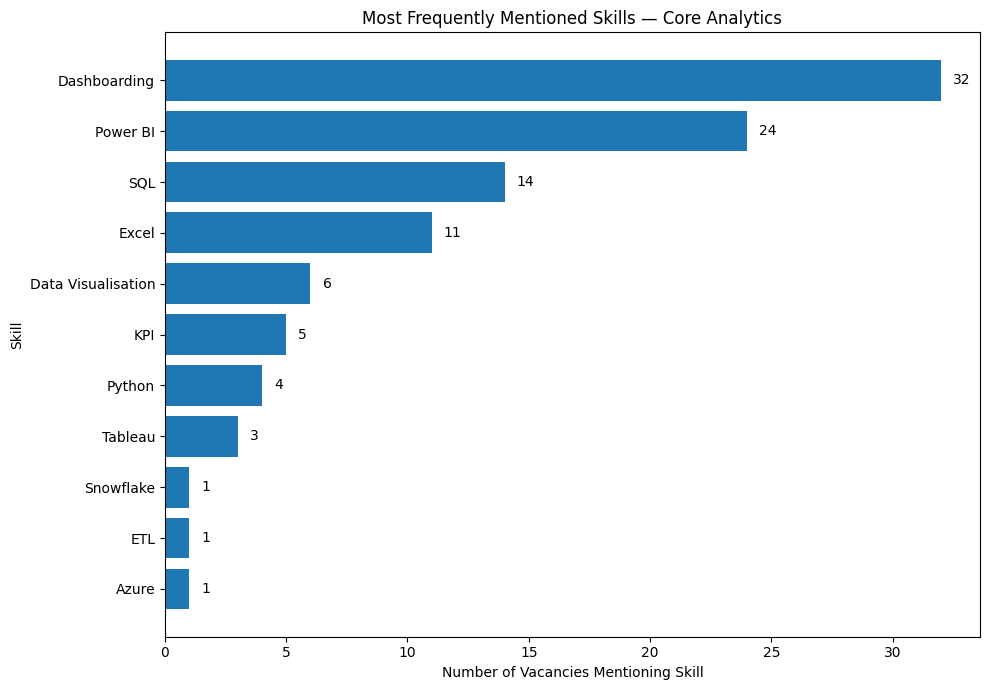

In [26]:
top_skills = (
    skill_summary
    .head(15)
    .sort_values("vacancies")
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top_skills["skill"],
    top_skills["vacancies"]
)

ax.set_title(
    "Most Frequently Mentioned Skills — Core Analytics"
)

ax.set_xlabel(
    "Number of Vacancies Mentioning Skill"
)

ax.set_ylabel("Skill")

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [27]:
no_skill_jobs = (
    core_market[
        core_market["skills_count"] == 0
    ][
        [
            "job_id",
            "title",
            "job_family",
            "description",
            "description_clean"
        ]
    ]
    .copy()
)

print("No-skill records:", len(no_skill_jobs))

no_skill_sample = no_skill_jobs.sample(
    min(30, len(no_skill_jobs)),
    random_state=42
)

for _, row in no_skill_sample.iterrows():

    print("=" * 100)
    print("TITLE:", row["title"])
    print("FAMILY:", row["job_family"])
    print()

    print(row["description"])
    print()

No-skill records: 188
TITLE: Data & Tracking Analyst (Liverpool)
FAMILY: Data Analyst

Data & Analytics team 3 days a week in the office, Leeds, Liverpool or Dunfermline £35,000 to £45,000, depending on experience Velstar is a full-service eCommerce agency working across DTC and B2B. We build on Shopify Plus, and on our own proprietary platform, for complex B2B requirements that need greater scale, reliability and compliance. Our Data & Analytics team is growing, and we're hiring a Tracking & Reporting Analyst to build out the tracking, reporting and data work our clients rely on…

TITLE: Regulatory Reporting Analyst – Open Banking
FAMILY: Reporting Analytics

Description EXL (NASDAQ: EXLS) is a global data and artificial intelligence ("AI") company that offers services and solutions to reinvent client business models, drive better outcomes and unlock growth with speed. EXL harnesses the power of data, AI, and deep industry knowledge to transform businesses, including the world’s leadi

In [28]:
from sklearn.feature_extraction.text import CountVectorizer

In [29]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 3),
    min_df=2,
    max_features=100
)

X = vectorizer.fit_transform(
    no_skill_jobs["description_clean"]
)

term_counts = np.asarray(
    X.sum(axis=0)
).ravel()

terms = vectorizer.get_feature_names_out()

unmatched_terms = (
    pd.DataFrame({
        "term": terms,
        "mentions": term_counts
    })
    .sort_values(
        "mentions",
        ascending=False
    )
    .reset_index(drop=True)
)

unmatched_terms.head(50)

,term,mentions
0,data,379
1,analyst,235
2,business,154
3,role,133
4,data analyst,132
5,reporting,124
6,team,103
7,join,79
8,working,73
9,intelligence,62


In [30]:
phrase_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 3),
    min_df=2,
    max_features=100
)

X_phrases = phrase_vectorizer.fit_transform(
    no_skill_jobs["description_clean"]
)

phrase_counts = np.asarray(
    X_phrases.sum(axis=0)
).ravel()

phrases = phrase_vectorizer.get_feature_names_out()

unmatched_phrases = (
    pd.DataFrame({
        "phrase": phrases,
        "mentions": phrase_counts
    })
    .sort_values(
        "mentions",
        ascending=False
    )
    .reset_index(drop=True)
)

unmatched_phrases.head(50)

,phrase,mentions
0,data analyst,132
1,analyst join,47
2,business intelligence,40
3,reporting analyst,36
4,data analyst join,32
5,decision making,28
6,data analytics,27
7,intelligence analyst,25
8,key role,23
9,play key,23


### Initial Skill-Extraction Diagnostic

The first high-precision skill dictionary detected at least one explicit skill
mention in 56 of 244 Core Analytics vacancies.

A total of 188 vacancies (77.0%) contained no matches from the initial
dictionary.

This does not imply an absence of skill requirements. The high unmatched rate
likely reflects both the limited scope of the initial dictionary and the
truncated nature of Adzuna description snippets.

The taxonomy is therefore refined iteratively using corpus-derived term and
phrase analysis before final skill frequencies are calculated.

In [31]:
candidate_skill_patterns = {

    "R": r"(?<![a-zA-Z])R(?![a-zA-Z])",

    "DAX": r"\bdax\b",

    "Power Query": r"\bpower\s+query\b",

    "Power Pivot": r"\bpower\s+pivot\b",

    "VBA": r"\bvba\b",

    "SQL Server": r"\bsql\s+server\b",

    "SSRS": r"\bssrs\b|sql server reporting services",

    "SSIS": r"\bssis\b|sql server integration services",

    "Alteryx": r"\balteryx\b",

    "SAS": r"\bsas\b",

    "SPSS": r"\bspss\b",

    "Oracle": r"\boracle\b",

    "SAP": r"\bsap\b",

    "Salesforce": r"\bsalesforce\b",

    "Google Analytics": r"\bgoogle analytics\b",

    "Looker Studio": r"\blooker studio\b",

    "Redshift": r"\bredshift\b",

    "PostgreSQL": r"\bpostgres(?:ql)?\b",

    "MySQL": r"\bmysql\b",

    "PySpark": r"\bpyspark\b",

    "Spark": r"\bapache spark\b|\bspark\b",

    "Pandas": r"\bpandas\b",

    "NumPy": r"\bnumpy\b",

    "Jupyter": r"\bjupyter\b",

    "Jira": r"\bjira\b"
}

In [32]:
candidate_skill_results = []

for skill, pattern in candidate_skill_patterns.items():

    count = (
        core_market["description"]
        .fillna("")
        .str.contains(
            pattern,
            case=False,
            regex=True
        )
        .sum()
    )

    candidate_skill_results.append(
        {
            "skill": skill,
            "vacancies": count
        }
    )

candidate_skill_audit = (
    pd.DataFrame(candidate_skill_results)
    .sort_values(
        "vacancies",
        ascending=False
    )
    .reset_index(drop=True)
)

candidate_skill_audit

,skill,vacancies
0,R,4
1,SQL Server,2
2,Power Query,1
3,Oracle,1
4,SAP,1
5,Jira,1
6,Salesforce,1
7,Power Pivot,0
8,DAX,0
9,Alteryx,0


### Corpus-Derived Taxonomy Review

N-gram analysis of vacancies without initial skill matches showed that the
most frequent expressions were primarily occupational and contextual terms,
including "data analyst", "business intelligence", "reporting analyst",
"data analysis" and "decision making".

These terms were not automatically added to the technical-skills dictionary,
as doing so would conflate occupational language with specific tools or
technologies.

Instead, the taxonomy was separated into technical technologies and broader
analytical capabilities.

In [33]:
r_pattern = r"(?<![A-Za-z])R(?![A-Za-z])"

r_matches = core_market[
    core_market["description"]
    .fillna("")
    .str.contains(
        r_pattern,
        regex=True,
        na=False
    )
][
    [
        "job_id",
        "title",
        "company",
        "description"
    ]
]

print("Case-sensitive R matches:", len(r_matches))

r_matches

Case-sensitive R matches: 2


,job_id,title,company,description
37,5835867417,Data Analyst,No1 Legal and Professional,Data Analyst Great opportunity to work at a su...
98,5840201257,Data Analyst,Catalyst,"Salary: £50,000 - 80,000 per year Requirements..."


In [34]:
capability_patterns = {

    "Data Analysis":
        r"\bdata analysis\b|\banalyse data\b|\banalyze data\b",

    "Reporting":
        r"\breporting\b|\breport development\b",

    "Dashboarding":
        r"\bdashboards?\b|\bdashboard development\b",

    "Data Visualisation":
        r"data visuali[sz]ation|visuali[sz]e data",

    "Data Modelling":
        r"\bdata modelling\b|\bdata modeling\b",

    "Data Quality":
        r"\bdata quality\b",

    "Data Governance":
        r"\bdata governance\b",

    "Statistics":
        r"\bstatistics?\b|\bstatistical analysis\b",

    "KPI":
        r"\bkpis?\b|key performance indicators?",

    "Forecasting":
        r"\bforecasting\b|\bforecast\b",

    "Stakeholder Management":
        r"\bstakeholder management\b|"
        r"\bstakeholder engagement\b",

    "Requirements Gathering":
        r"\brequirements gathering\b|"
        r"\bgathering requirements\b",

    "Data Cleaning":
        r"\bdata cleaning\b|"
        r"\bcleaning data\b",

    "Data Transformation":
        r"\bdata transformation\b|"
        r"\btransforming data\b",

    "Data Storytelling":
        r"\bdata storytelling\b|"
        r"\bstorytelling with data\b"
}

In [35]:
capability_results = []

for capability, pattern in capability_patterns.items():

    count = (
        core_market["description_clean"]
        .str.contains(
            pattern,
            case=False,
            regex=True,
            na=False
        )
        .sum()
    )

    capability_results.append({
        "capability": capability,
        "vacancies": count,
        "mention_share_pct": round(
            count / len(core_market) * 100,
            1
        )
    })

In [36]:
capability_summary = (
    pd.DataFrame(capability_results)
    .sort_values(
        "vacancies",
        ascending=False
    )
    .reset_index(drop=True)
)

capability_summary

,capability,vacancies,mention_share_pct
0,Reporting,98,40.2
1,Dashboarding,32,13.1
2,Data Analysis,20,8.2
3,Data Transformation,8,3.3
4,Data Visualisation,6,2.5
5,KPI,5,2.0
6,Data Quality,5,2.0
7,Data Modelling,3,1.2
8,Forecasting,1,0.4
9,Data Governance,0,0.0


In [37]:
r_pattern = r"(?<![A-Za-z])R(?![A-Za-z])"

r_matches = core_market[
    core_market["description"]
    .fillna("")
    .str.contains(
        r_pattern,
        regex=True,
        na=False
    )
][
    [
        "job_id",
        "title",
        "company",
        "description"
    ]
]

print("Case-sensitive R matches:", len(r_matches))

r_matches[
    [
        "job_id",
        "title",
        "company"
    ]
]

Case-sensitive R matches: 2


,job_id,title,company
37,5835867417,Data Analyst,No1 Legal and Professional
98,5840201257,Data Analyst,Catalyst


In [38]:
for _, row in r_matches.iterrows():

    print("=" * 100)
    print("TITLE:", row["title"])
    print("COMPANY:", row["company"])
    print()

    print(row["description"])
    print()

TITLE: Data Analyst
COMPANY: No1 Legal and Professional

Data Analyst Great opportunity to work at a successful electronics distributor Previous experience as a data analyst Data Analyst Experience translating business problems into analytical solutions Experience of data modelling principles, including dimensional modelling, relational databases and business logic design. Data Analyst PowerBI for data visualisation and dashboard creation SQL for data extraction and manipulation and analysis Python or R for analysis and automation Experience carrying…

TITLE: Data Analyst
COMPANY: Catalyst

Salary: £50,000 - 80,000 per year Requirements: Strong commercial Data Analyst experience in a similar role, preferably in a fast-moving, growing health or tech consumer product/service business Degree or equivalent in Data, Tech or a numerate discipline Strong SQL skills and confidence working with large datasets; Python or R experience for data analysis is beneficial Proficient in Excel and at lea

In [39]:
technology_patterns = {

    # Programming / query
    "SQL": r"\bsql\b",
    "Python": r"\bpython\b",

    # Spreadsheet
    "Excel": r"\bexcel\b|microsoft excel",

    # BI / visualisation tools
    "Power BI": r"\bpower\s*bi\b|powerbi",
    "Tableau": r"\btableau\b",
    "Looker": r"\blooker\b",
    "Qlik": r"\bqlik(?:view|sense)?\b",

    # Data platforms
    "Snowflake": r"\bsnowflake\b",
    "BigQuery": r"\bbigquery\b|big query",
    "Databricks": r"\bdatabricks\b",
    "SQL Server": r"\bsql\s+server\b",

    # Cloud
    "Azure": r"\bazure\b",
    "AWS": r"\baws\b|amazon web services",
    "Google Cloud": r"\bgoogle cloud\b|\bgcp\b",

    # Transformation
    "ETL": r"\betl\b",
    "dbt": r"\bdbt\b",
    "Power Query": r"\bpower\s+query\b",

    # Enterprise platforms
    "Oracle": r"\boracle\b",
    "SAP": r"\bsap\b",
    "Salesforce": r"\bsalesforce\b",

    # Delivery / collaboration
    "Jira": r"\bjira\b",

    # Version control
    "Git": r"\bgit\b|github|gitlab"
}

In [40]:
def extract_pattern_matches(text, patterns):

    found = []

    for item, pattern in patterns.items():

        if re.search(
            pattern,
            text,
            flags=re.IGNORECASE
        ):
            found.append(item)

    return found

In [41]:
core_market["technologies_found"] = (
    core_market["description_clean"]
    .apply(
        lambda x: extract_pattern_matches(
            x,
            technology_patterns
        )
    )
)

In [42]:
technology_long = (
    core_market[
        [
            "job_id",
            "title",
            "job_family",
            "seniority",
            "salary_midpoint",
            "salary_is_predicted",
            "technologies_found"
        ]
    ]
    .explode("technologies_found")
    .rename(
        columns={
            "technologies_found": "technology"
        }
    )
)

technology_long = (
    technology_long[
        technology_long["technology"].notna()
    ]
    .reset_index(drop=True)
)

In [43]:
technology_summary = (
    technology_long["technology"]
    .value_counts()
    .rename_axis("technology")
    .reset_index(name="vacancies")
)

technology_summary["mention_share_pct"] = (
    technology_summary["vacancies"]
    / len(core_market)
    * 100
).round(1)

technology_summary

,technology,vacancies,mention_share_pct
0,Power BI,24,9.8
1,SQL,14,5.7
2,Excel,11,4.5
3,Python,4,1.6
4,Tableau,3,1.2
5,SQL Server,2,0.8
6,Snowflake,1,0.4
7,Salesforce,1,0.4
8,Azure,1,0.4
9,Power Query,1,0.4


In [44]:
core_market["capabilities_found"] = (
    core_market["description_clean"]
    .apply(
        lambda x: extract_pattern_matches(
            x,
            capability_patterns
        )
    )
)

In [45]:
capability_long = (
    core_market[
        [
            "job_id",
            "title",
            "job_family",
            "seniority",
            "salary_midpoint",
            "salary_is_predicted",
            "capabilities_found"
        ]
    ]
    .explode("capabilities_found")
    .rename(
        columns={
            "capabilities_found": "capability"
        }
    )
)

capability_long = (
    capability_long[
        capability_long["capability"].notna()
    ]
    .reset_index(drop=True)
)

In [46]:
technology_summary

,technology,vacancies,mention_share_pct
0,Power BI,24,9.8
1,SQL,14,5.7
2,Excel,11,4.5
3,Python,4,1.6
4,Tableau,3,1.2
5,SQL Server,2,0.8
6,Snowflake,1,0.4
7,Salesforce,1,0.4
8,Azure,1,0.4
9,Power Query,1,0.4


In [47]:
capability_summary

,capability,vacancies,mention_share_pct
0,Reporting,98,40.2
1,Dashboarding,32,13.1
2,Data Analysis,20,8.2
3,Data Transformation,8,3.3
4,Data Visualisation,6,2.5
5,KPI,5,2.0
6,Data Quality,5,2.0
7,Data Modelling,3,1.2
8,Forecasting,1,0.4
9,Data Governance,0,0.0


## 7. Technology Mentions by Job Family

Technology mentions are compared across standardised analytical job families.

Because job families contain different numbers of vacancies, raw mention
counts are supplemented with within-family mention rates.

A technology not mentioned in a description snippet should not be interpreted
as absent from the full job requirements.

In [48]:
technology_family_counts = (
    technology_long
    .groupby(
        ["technology", "job_family"]
    )
    .size()
    .reset_index(name="vacancies")
)

technology_family_counts

,technology,job_family,vacancies
0,Azure,Data Analyst,1
1,ETL,Business Intelligence,1
2,Excel,Business Intelligence,3
3,Excel,Data Analyst,7
4,Excel,Reporting Analytics,1
5,Jira,Business Intelligence,1
6,Oracle,Data Analyst,1
7,Power BI,Business Intelligence,4
8,Power BI,Data Analyst,18
9,Power BI,Management Information,1


In [49]:
technology_family_pivot = (
    technology_family_counts
    .pivot(
        index="technology",
        columns="job_family",
        values="vacancies"
    )
    .fillna(0)
    .astype(int)
)

technology_family_pivot

job_family,Business Intelligence,Data Analyst,Management Information,Reporting Analytics
technology,,,,
Azure,0,1,0,0
ETL,1,0,0,0
Excel,3,7,0,1
Jira,1,0,0,0
Oracle,0,1,0,0
Power BI,4,18,1,1
Power Query,1,0,0,0
Python,1,3,0,0
SAP,0,1,0,0


In [50]:
family_sizes = (
    core_market["job_family"]
    .value_counts()
)

technology_family_rate = (
    technology_family_pivot
    .div(
        family_sizes,
        axis="columns"
    )
    * 100
)

technology_family_rate = (
    technology_family_rate
    .round(1)
)

technology_family_rate

job_family,Business Intelligence,Data Analyst,Insights Analytics,Management Information,Reporting Analytics
technology,,,,,
Azure,0.0,0.7,NaN,0.0,0.0
ETL,2.2,0.0,NaN,0.0,0.0
Excel,6.5,4.9,NaN,0.0,2.2
Jira,2.2,0.0,NaN,0.0,0.0
Oracle,0.0,0.7,NaN,0.0,0.0
Power BI,8.7,12.6,NaN,50.0,2.2
Power Query,2.2,0.0,NaN,0.0,0.0
Python,2.2,2.1,NaN,0.0,0.0
SAP,0.0,0.7,NaN,0.0,0.0


In [51]:
heatmap_technologies = (
    technology_summary.loc[
        technology_summary["vacancies"] >= 3,
        "technology"
    ]
    .tolist()
)

heatmap_technologies

['Power BI', 'SQL', 'Excel', 'Python', 'Tableau']

In [52]:
technology_heatmap_data = (
    technology_family_rate
    .loc[heatmap_technologies]
)

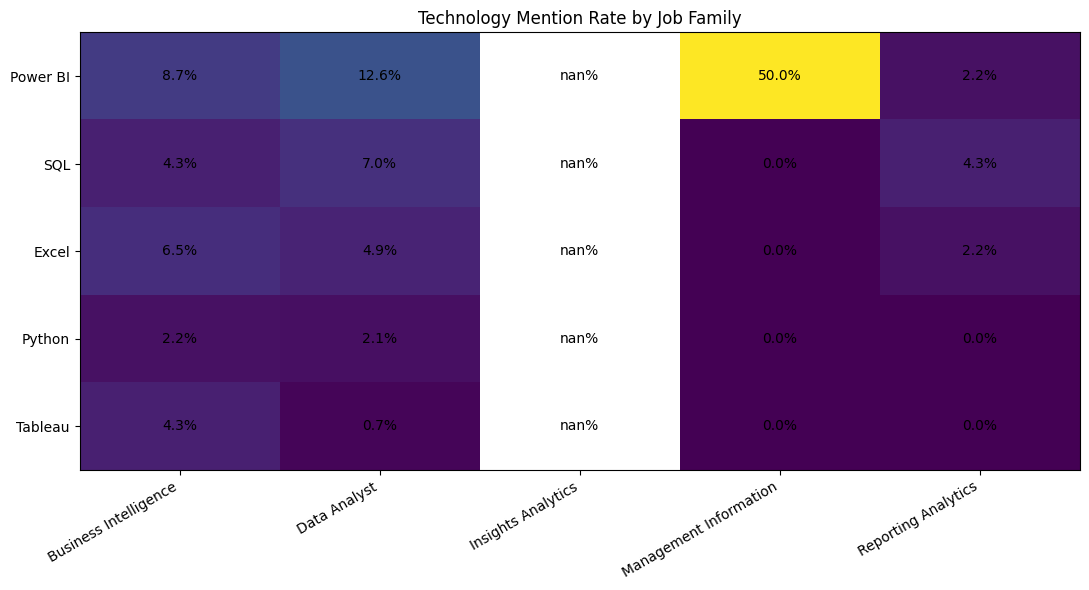

In [53]:
fig, ax = plt.subplots(figsize=(11, 6))

im = ax.imshow(
    technology_heatmap_data.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(technology_heatmap_data.columns))
)

ax.set_xticklabels(
    technology_heatmap_data.columns,
    rotation=30,
    ha="right"
)

ax.set_yticks(
    range(len(technology_heatmap_data.index))
)

ax.set_yticklabels(
    technology_heatmap_data.index
)

ax.set_title(
    "Technology Mention Rate by Job Family"
)

for i in range(len(technology_heatmap_data.index)):
    for j in range(len(technology_heatmap_data.columns)):

        value = technology_heatmap_data.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [54]:
capability_family_counts = (
    capability_long
    .groupby(
        ["capability", "job_family"]
    )
    .size()
    .reset_index(name="vacancies")
)

In [55]:
capability_family_pivot = (
    capability_family_counts
    .pivot(
        index="capability",
        columns="job_family",
        values="vacancies"
    )
    .fillna(0)
    .astype(int)
)

In [56]:
capability_family_rate = (
    capability_family_pivot
    .div(
        family_sizes,
        axis="columns"
    )
    * 100
).round(1)

capability_family_rate

job_family,Business Intelligence,Data Analyst,Insights Analytics,Management Information,Reporting Analytics
capability,,,,,
Dashboarding,8.7,16.1,14.3,0.0,8.7
Data Analysis,4.3,9.1,0.0,0.0,10.9
Data Modelling,0.0,2.1,0.0,0.0,0.0
Data Quality,0.0,3.5,0.0,0.0,0.0
Data Transformation,4.3,2.8,14.3,0.0,2.2
Data Visualisation,0.0,4.2,0.0,0.0,0.0
Forecasting,2.2,0.0,0.0,0.0,0.0
KPI,0.0,2.8,0.0,0.0,2.2
Reporting,30.4,28.7,57.1,50.0,82.6


In [57]:
heatmap_capabilities = (
    capability_summary.loc[
        capability_summary["vacancies"] >= 3,
        "capability"
    ]
    .tolist()
)

heatmap_capabilities


['Reporting',
 'Dashboarding',
 'Data Analysis',
 'Data Transformation',
 'Data Visualisation',
 'KPI',
 'Data Quality',
 'Data Modelling']

In [58]:
capability_heatmap_data = (
    capability_family_rate
    .loc[heatmap_capabilities]
)

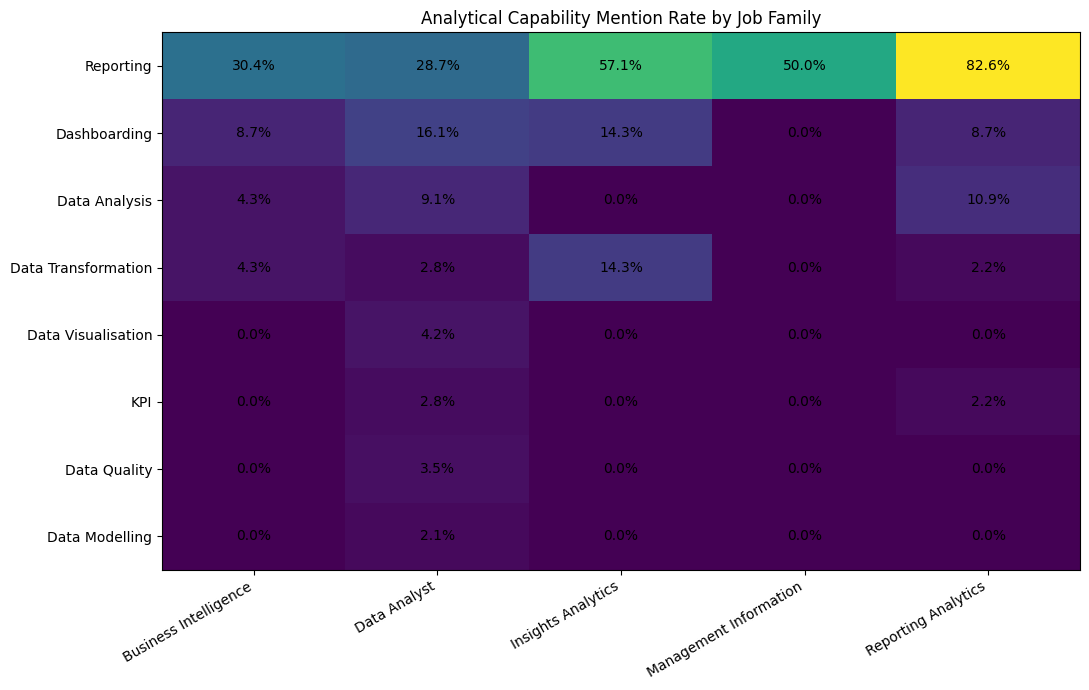

In [59]:
fig, ax = plt.subplots(figsize=(11, 7))

im = ax.imshow(
    capability_heatmap_data.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(capability_heatmap_data.columns))
)

ax.set_xticklabels(
    capability_heatmap_data.columns,
    rotation=30,
    ha="right"
)

ax.set_yticks(
    range(len(capability_heatmap_data.index))
)

ax.set_yticklabels(
    capability_heatmap_data.index
)

ax.set_title(
    "Analytical Capability Mention Rate by Job Family"
)

for i in range(len(capability_heatmap_data.index)):
    for j in range(len(capability_heatmap_data.columns)):

        value = capability_heatmap_data.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

### Technology and Capability Patterns — Observation

Technology mentions vary across analytical job families, although overall
technology coverage remains limited by the available description snippets.

Within Data Analyst vacancies, Power BI is the most frequently observed
technology, followed by SQL and Excel. Business Intelligence vacancies also
show mentions of Power BI, Excel, SQL and Tableau.

Reporting Analytics contains relatively few explicit technology mentions,
while the broader capability "Reporting" appears in 82.6% of its available
description snippets.

This contrast reinforces an important limitation of the source data:
description snippets appear more likely to capture the nature of analytical
work than the complete technical requirements of a vacancy.

Percentages for Insights Analytics and Management Information should be
interpreted cautiously because these job families contain only 7 and 2
vacancies respectively.

## 8. Technology Co-occurrence

Technology co-occurrence is examined to identify combinations of tools that
are mentioned together within the same vacancy description snippet.

Because technical mentions are sparse, co-occurrence results are interpreted
as observed combinations rather than definitive technology stacks required by
the wider market.

In [60]:
from itertools import combinations
from collections import Counter

In [62]:
technology_pairs = Counter()

for technologies in core_market["technologies_found"]:

    unique_technologies = sorted(set(technologies))

    for pair in combinations(
        unique_technologies,
        2
    ):
        technology_pairs[pair] += 1

In [63]:
technology_pairs = Counter()

for technologies in core_market["technologies_found"]:

    unique_technologies = sorted(set(technologies))

    for pair in combinations(
        unique_technologies,
        2
    ):
        technology_pairs[pair] += 1

In [64]:
technology_pair_summary = (
    pd.DataFrame(
        [
            {
                "technology_1": pair[0],
                "technology_2": pair[1],
                "co_mentions": count
            }
            for pair, count
            in technology_pairs.items()
        ]
    )
    .sort_values(
        "co_mentions",
        ascending=False
    )
    .reset_index(drop=True)
)

technology_pair_summary

,technology_1,technology_2,co_mentions
0,Excel,Power BI,7
1,Power BI,SQL,6
2,Excel,SQL,6
3,Python,SQL,4
4,Excel,Python,3
5,Power BI,Python,2
6,SQL,SQL Server,2
7,Power BI,SQL Server,1
8,Power BI,Snowflake,1
9,SQL,Snowflake,1


In [65]:
technology_binary = pd.DataFrame(
    {
        technology:
        core_market["technologies_found"]
        .apply(
            lambda skills:
            int(technology in skills)
        )
        for technology
        in technology_summary["technology"]
    }
)

In [66]:
technology_binary.head()

,Power BI,SQL,Excel,Python,Tableau,SQL Server,Snowflake,Salesforce,Azure,Power Query,Jira,Oracle,SAP,ETL
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [67]:
technology_cooccurrence = (
    technology_binary.T
    @ technology_binary
)

technology_cooccurrence

,Power BI,SQL,Excel,Python,Tableau,SQL Server,Snowflake,Salesforce,Azure,Power Query,Jira,Oracle,SAP,ETL
Power BI,24,6,7,2,1,1,1,0,0,1,0,1,1,0
SQL,6,14,6,4,1,2,1,0,0,1,1,0,0,0
Excel,7,6,11,3,1,0,0,0,0,1,1,0,0,0
Python,2,4,3,4,1,0,0,0,0,0,1,0,0,0
Tableau,1,1,1,1,3,0,0,0,0,0,0,0,0,0
SQL Server,1,2,0,0,0,2,1,0,0,0,0,0,0,0
Snowflake,1,1,0,0,0,1,1,0,0,0,0,0,0,0
Salesforce,0,0,0,0,0,0,0,1,0,0,0,0,0,0
Azure,0,0,0,0,0,0,0,0,1,0,0,0,0,0
Power Query,1,1,1,0,0,0,0,0,0,1,0,0,0,0


In [68]:
cooccurrence_technologies = (
    technology_summary.loc[
        technology_summary["vacancies"] >= 3,
        "technology"
    ]
    .tolist()
)

cooccurrence_heatmap = (
    technology_cooccurrence.loc[
        cooccurrence_technologies,
        cooccurrence_technologies
    ]
)

cooccurrence_heatmap

,Power BI,SQL,Excel,Python,Tableau
Power BI,24,6,7,2,1
SQL,6,14,6,4,1
Excel,7,6,11,3,1
Python,2,4,3,4,1
Tableau,1,1,1,1,3


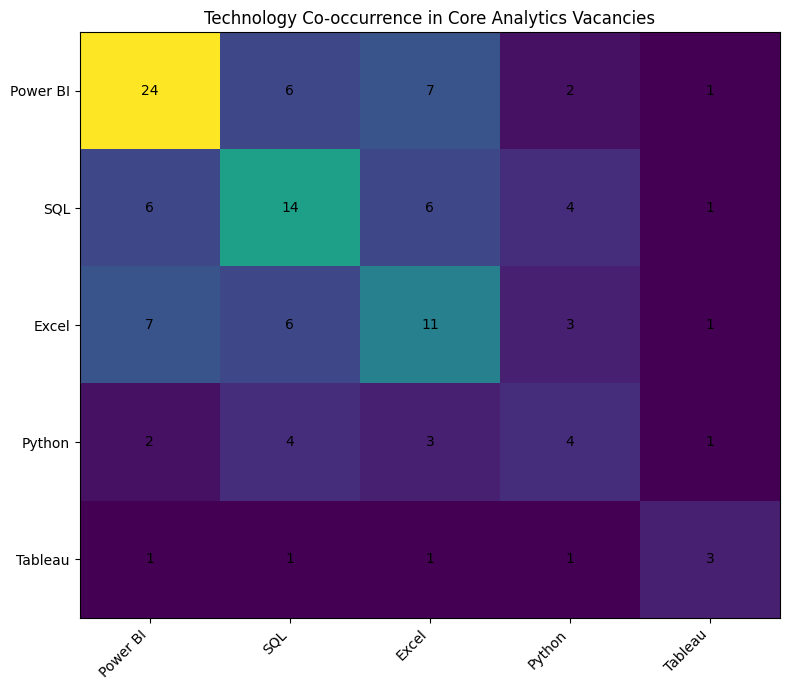

In [69]:
fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    cooccurrence_heatmap.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(cooccurrence_heatmap.columns))
)

ax.set_xticklabels(
    cooccurrence_heatmap.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    range(len(cooccurrence_heatmap.index))
)

ax.set_yticklabels(
    cooccurrence_heatmap.index
)

ax.set_title(
    "Technology Co-occurrence in Core Analytics Vacancies"
)

for i in range(len(cooccurrence_heatmap.index)):
    for j in range(len(cooccurrence_heatmap.columns)):

        value = cooccurrence_heatmap.iloc[i, j]

        ax.text(
            j,
            i,
            f"{int(value)}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [70]:
def jaccard_similarity(col_a, col_b):

    intersection = (
        (col_a == 1)
        &
        (col_b == 1)
    ).sum()

    union = (
        (col_a == 1)
        |
        (col_b == 1)
    ).sum()

    if union == 0:
        return 0

    return intersection / union

In [71]:
jaccard_results = []

for tech_a, tech_b in combinations(
    cooccurrence_technologies,
    2
):

    score = jaccard_similarity(
        technology_binary[tech_a],
        technology_binary[tech_b]
    )

    co_mentions = (
        (
            technology_binary[tech_a] == 1
        )
        &
        (
            technology_binary[tech_b] == 1
        )
    ).sum()

    jaccard_results.append({
        "technology_1": tech_a,
        "technology_2": tech_b,
        "co_mentions": co_mentions,
        "jaccard_similarity": round(
            score,
            3
        )
    })

technology_jaccard = (
    pd.DataFrame(jaccard_results)
    .sort_values(
        [
            "co_mentions",
            "jaccard_similarity"
        ],
        ascending=False
    )
)

technology_jaccard

,technology_1,technology_2,co_mentions,jaccard_similarity
1,Power BI,Excel,7,0.250
4,SQL,Excel,6,0.316
0,Power BI,SQL,6,0.188
5,SQL,Python,4,0.286
7,Excel,Python,3,0.250
2,Power BI,Python,2,0.077
9,Python,Tableau,1,0.167
8,Excel,Tableau,1,0.077
6,SQL,Tableau,1,0.062
3,Power BI,Tableau,1,0.038


### Technology Co-occurrence — Observation

Technology mentions are relatively sparse, but several recurring combinations
are visible in the Core Analytics sample.

Excel and Power BI are mentioned together in 7 vacancy snippets, while
Power BI and SQL, and Excel and SQL, each co-occur in 6.

When co-occurrence is normalised using Jaccard similarity, SQL and Excel show
the strongest observed association among technologies with at least three
individual mentions, followed by SQL and Python.

These results should be interpreted as observed technology combinations rather
than representative market-wide technology stacks because technical
requirements are incompletely captured by the available description snippets.

## 9. Technology Mentions and Advertised Salary

This section explores whether explicit technology mentions are associated with
differences in advertised salary.

Only non-predicted salary observations are used.

Results are descriptive associations and should not be interpreted as the
salary premium caused by possessing a particular technology, since geography,
seniority, job family and other factors may also influence compensation.

In [72]:
advertised_market = (
    core_market[
        core_market["salary_is_predicted"] == 0
    ]
    .copy()
)

print(
    "Advertised salary observations:",
    len(advertised_market)
)

Advertised salary observations: 120


In [73]:
technology_salary_results = []

for technology in technology_summary["technology"]:

    mentioned_mask = (
        advertised_market["technologies_found"]
        .apply(
            lambda items:
            technology in items
        )
    )

    mentioned = advertised_market[
        mentioned_mask
    ]["salary_midpoint"].dropna()

    not_mentioned = advertised_market[
        ~mentioned_mask
    ]["salary_midpoint"].dropna()

    if len(mentioned) == 0:
        continue

    technology_salary_results.append({
        "technology": technology,
        "mentioned_vacancies": len(mentioned),
        "median_salary_mentioned": mentioned.median(),
        "mean_salary_mentioned": mentioned.mean(),
        "median_salary_not_mentioned": not_mentioned.median()
    })

In [74]:
technology_salary_summary = (
    pd.DataFrame(
        technology_salary_results
    )
)

In [75]:
technology_salary_summary[
    "median_difference_pct"
] = (
    (
        technology_salary_summary[
            "median_salary_mentioned"
        ]
        -
        technology_salary_summary[
            "median_salary_not_mentioned"
        ]
    )
    /
    technology_salary_summary[
        "median_salary_not_mentioned"
    ]
    * 100
).round(1)

In [76]:
salary_columns = [
    "median_salary_mentioned",
    "mean_salary_mentioned",
    "median_salary_not_mentioned"
]

technology_salary_summary[
    salary_columns
] = (
    technology_salary_summary[
        salary_columns
    ]
    .round(2)
)

In [77]:
technology_salary_summary.sort_values(
    "mentioned_vacancies",
    ascending=False
)

,technology,mentioned_vacancies,median_salary_mentioned,mean_salary_mentioned,median_salary_not_mentioned,median_difference_pct
0,Power BI,18,45000.0,50388.89,43500.0,3.4
1,SQL,10,43750.0,49360.00,44750.0,-2.2
2,Excel,7,45000.0,50857.14,43500.0,3.4
4,Tableau,3,56000.0,58666.67,43500.0,28.7
3,Python,2,62500.0,62500.00,44000.0,42.0
5,SQL Server,2,40500.0,40500.00,44750.0,-9.5
6,Snowflake,1,45000.0,45000.00,44500.0,1.1
7,Salesforce,1,35200.0,35200.00,45000.0,-21.8
8,Azure,1,69550.0,69550.00,44500.0,56.3
9,Power Query,1,28000.0,28000.00,45000.0,-37.8


In [78]:
technology_salary_robust = (
    technology_salary_summary[
        technology_salary_summary[
            "mentioned_vacancies"
        ] >= 5
    ]
    .sort_values(
        "median_salary_mentioned",
        ascending=False
    )
    .copy()
)

technology_salary_robust

,technology,mentioned_vacancies,median_salary_mentioned,mean_salary_mentioned,median_salary_not_mentioned,median_difference_pct
0,Power BI,18,45000.0,50388.89,43500.0,3.4
2,Excel,7,45000.0,50857.14,43500.0,3.4
1,SQL,10,43750.0,49360.00,44750.0,-2.2


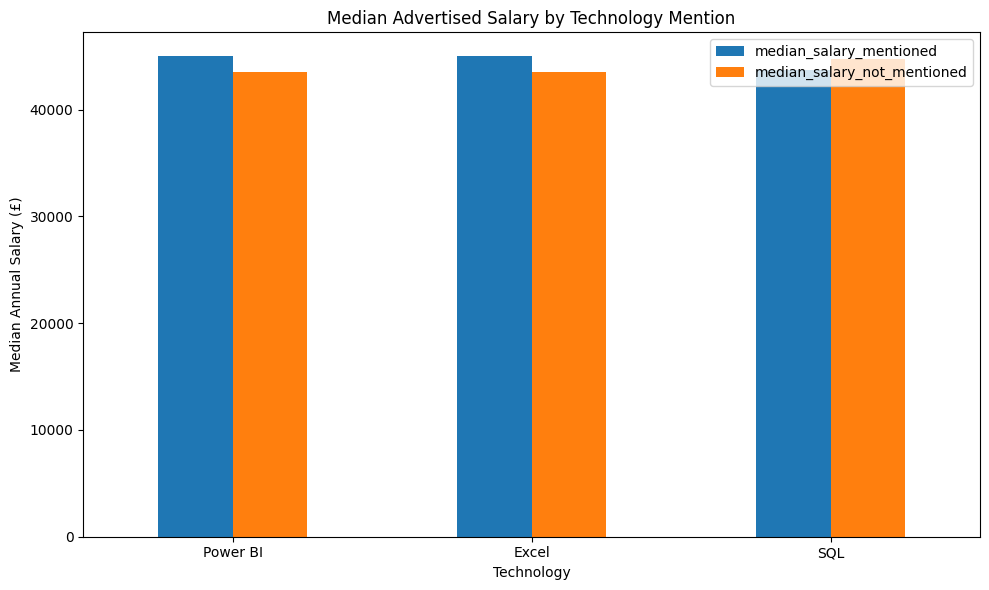

In [79]:
salary_plot_data = (
    technology_salary_robust[
        [
            "technology",
            "median_salary_mentioned",
            "median_salary_not_mentioned"
        ]
    ]
    .set_index("technology")
)

ax = salary_plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Median Advertised Salary by Technology Mention"
)

ax.set_xlabel("Technology")
ax.set_ylabel("Median Annual Salary (£)")

ax.tick_params(
    axis="x",
    rotation=0
)

plt.tight_layout()
plt.show()

In [80]:
technology_salary_summary.sort_values(
    "mentioned_vacancies",
    ascending=False
)

,technology,mentioned_vacancies,median_salary_mentioned,mean_salary_mentioned,median_salary_not_mentioned,median_difference_pct
0,Power BI,18,45000.0,50388.89,43500.0,3.4
1,SQL,10,43750.0,49360.00,44750.0,-2.2
2,Excel,7,45000.0,50857.14,43500.0,3.4
4,Tableau,3,56000.0,58666.67,43500.0,28.7
3,Python,2,62500.0,62500.00,44000.0,42.0
5,SQL Server,2,40500.0,40500.00,44750.0,-9.5
6,Snowflake,1,45000.0,45000.00,44500.0,1.1
7,Salesforce,1,35200.0,35200.00,45000.0,-21.8
8,Azure,1,69550.0,69550.00,44500.0,56.3
9,Power Query,1,28000.0,28000.00,45000.0,-37.8


### Technology Mentions and Salary — Observation

Among technologies with at least five advertised-salary observations, no
large salary difference is visible.

Vacancies mentioning Power BI and Excel show median advertised salaries
approximately 3.4% higher than vacancies without those mentions, while SQL
shows a difference of approximately -2.2%.

These differences are small relative to the geographic and contract-related
salary differences observed earlier in the analysis.

Technologies with larger apparent salary differences, including Python and
Tableau, have insufficient sample sizes for reliable interpretation.

Technology mentions should not be interpreted as causal salary drivers because
job family, seniority, geography and other vacancy characteristics may
confound these relationships.

## 10. TF-IDF Analysis by Job Family

TF-IDF is used to explore terms and phrases that are relatively distinctive
across analytical job families.

Unlike the controlled technology and capability dictionaries, this method
derives vocabulary directly from the available description corpus.

Results describe characteristic language in Adzuna description snippets and
should not be interpreted as formal job requirements.

In [81]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [82]:
generic_job_words = [
    "analyst",
    "role",
    "roles",
    "team",
    "join",
    "joining",
    "opportunity",
    "opportunities",
    "work",
    "working",
    "looking",
    "support",
    "company",
    "organisation",
    "organization",
    "job",
    "position",
    "candidate",
    "candidates",
    "experience",
    "based",
    "uk"
]

In [83]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stop_words = (
    list(ENGLISH_STOP_WORDS)
    + generic_job_words
)

In [84]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words=custom_stop_words,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    max_features=500
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    core_market["description_clean"]
)

tfidf_terms = (
    tfidf_vectorizer
    .get_feature_names_out()
)

print(
    "TF-IDF matrix shape:",
    tfidf_matrix.shape
)

print(
    "Vocabulary size:",
    len(tfidf_terms)
)

TF-IDF matrix shape: (244, 500)
Vocabulary size: 500


In [85]:
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_terms,
    index=core_market.index
)

tfidf_df.head()

,00,000,000 50,000 year,12,2026,30,35,35 000,37,...,week office,wide,wide range,wider,workforce,world,world class,year,year requirements,years
0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.116576,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.279092,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [86]:
tfidf_df["job_family"] = (
    core_market["job_family"].values
)

In [87]:
family_tfidf = (
    tfidf_df
    .groupby("job_family")
    .mean()
)

family_tfidf

,00,000,000 50,000 year,12,2026,30,35,35 000,37,...,week office,wide,wide range,wider,workforce,world,world class,year,year requirements,years
job_family,,,,,,,,,,,,,,,,,,,,,
Business Intelligence,0.00000,0.031249,0.008361,0.007562,0.013737,0.006447,0.012832,0.003783,0.004293,0.011832,...,0.000000,0.010238,0.011202,0.004324,0.000000,0.052110,0.005378,0.010365,0.007562,0.019810
Data Analyst,0.00859,0.039179,0.002329,0.005872,0.008274,0.007085,0.004890,0.010933,0.006151,0.007547,...,0.007305,0.005244,0.003969,0.008742,0.009845,0.018804,0.006245,0.011816,0.005609,0.008935
Insights Analytics,0.00000,0.034480,0.000000,0.000000,0.000000,0.062701,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.036510,0.000000,0.000000,0.000000,0.025367
Management Information,0.00000,0.000000,0.000000,0.000000,0.178420,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.089210,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Reporting Analytics,0.00000,0.016110,0.006307,0.003150,0.000000,0.003920,0.000000,0.009625,0.005959,0.009286,...,0.000000,0.009578,0.004834,0.000000,0.000000,0.022267,0.017655,0.010733,0.003150,0.014625


In [88]:
def get_top_tfidf_terms(
    tfidf_grouped,
    family,
    n=15
):

    scores = (
        tfidf_grouped
        .loc[family]
        .sort_values(
            ascending=False
        )
        .head(n)
    )

    return pd.DataFrame({
        "term": scores.index,
        "tfidf_score": scores.values
    })

In [89]:
for family in family_tfidf.index:

    print("=" * 80)
    print("JOB FAMILY:", family)
    print()

    display(
        get_top_tfidf_terms(
            family_tfidf,
            family,
            n=15
        )
    )

JOB FAMILY: Business Intelligence



,term,tfidf_score
0,business intelligence,0.137604
1,intelligence,0.133588
2,business,0.101490
3,data,0.066803
4,bi,0.059145
5,world,0.052110
6,insight,0.047960
7,analysis,0.032875
8,people,0.032698
9,care,0.032179


JOB FAMILY: Data Analyst



,term,tfidf_score
0,data,0.167655
1,business,0.052591
2,000,0.039179
3,ll,0.037816
4,reporting,0.036351
5,analytics,0.032987
6,hybrid,0.030684
7,days,0.029787
8,analysis,0.028522
9,client,0.027949


JOB FAMILY: Insights Analytics



,term,tfidf_score
0,insights,0.107639
1,decisions,0.092152
2,ll,0.089163
3,reporting,0.087066
4,data,0.083061
5,trusted,0.080211
6,business,0.074088
7,insight,0.073386
8,lead,0.073369
9,shape,0.069966


JOB FAMILY: Management Information



,term,tfidf_score
0,mi,0.448954
1,hr,0.256957
2,systems,0.233190
3,12,0.178420
4,month,0.141367
5,business,0.125344
6,leading,0.105733
7,firm,0.091651
8,analytics,0.090715
9,wide,0.089210


JOB FAMILY: Reporting Analytics



,term,tfidf_score
0,reporting,0.147326
1,financial,0.086175
2,data,0.068026
3,business,0.059092
4,senior,0.049954
5,people,0.048770
6,finance,0.047504
7,key,0.046422
8,regulatory,0.039750
9,description,0.036044


In [90]:
top_terms_records = []

for family in family_tfidf.index:

    top_terms = (
        get_top_tfidf_terms(
            family_tfidf,
            family,
            n=15
        )
    )

    top_terms["job_family"] = family

    top_terms_records.append(
        top_terms
    )

top_terms_by_family = (
    pd.concat(
        top_terms_records,
        ignore_index=True
    )
)

top_terms_by_family[
    [
        "job_family",
        "term",
        "tfidf_score"
    ]
]

,job_family,term,tfidf_score
0,Business Intelligence,business intelligence,0.137604
1,Business Intelligence,intelligence,0.133588
2,Business Intelligence,business,0.101490
3,Business Intelligence,data,0.066803
4,Business Intelligence,bi,0.059145
...,...,...,...
70,Reporting Analytics,solutions,0.035860
71,Reporting Analytics,erp,0.033423
72,Reporting Analytics,management,0.033271
73,Reporting Analytics,global,0.033038


In [91]:
selected_terms = []

for family in family_tfidf.index:

    terms = (
        family_tfidf
        .loc[family]
        .sort_values(
            ascending=False
        )
        .head(5)
        .index
        .tolist()
    )

    selected_terms.extend(terms)

In [92]:
selected_terms = list(
    dict.fromkeys(selected_terms)
)

In [93]:
tfidf_heatmap_data = (
    family_tfidf[
        selected_terms
    ]
)

In [94]:
tfidf_heatmap_plot = (
    tfidf_heatmap_data.T
)

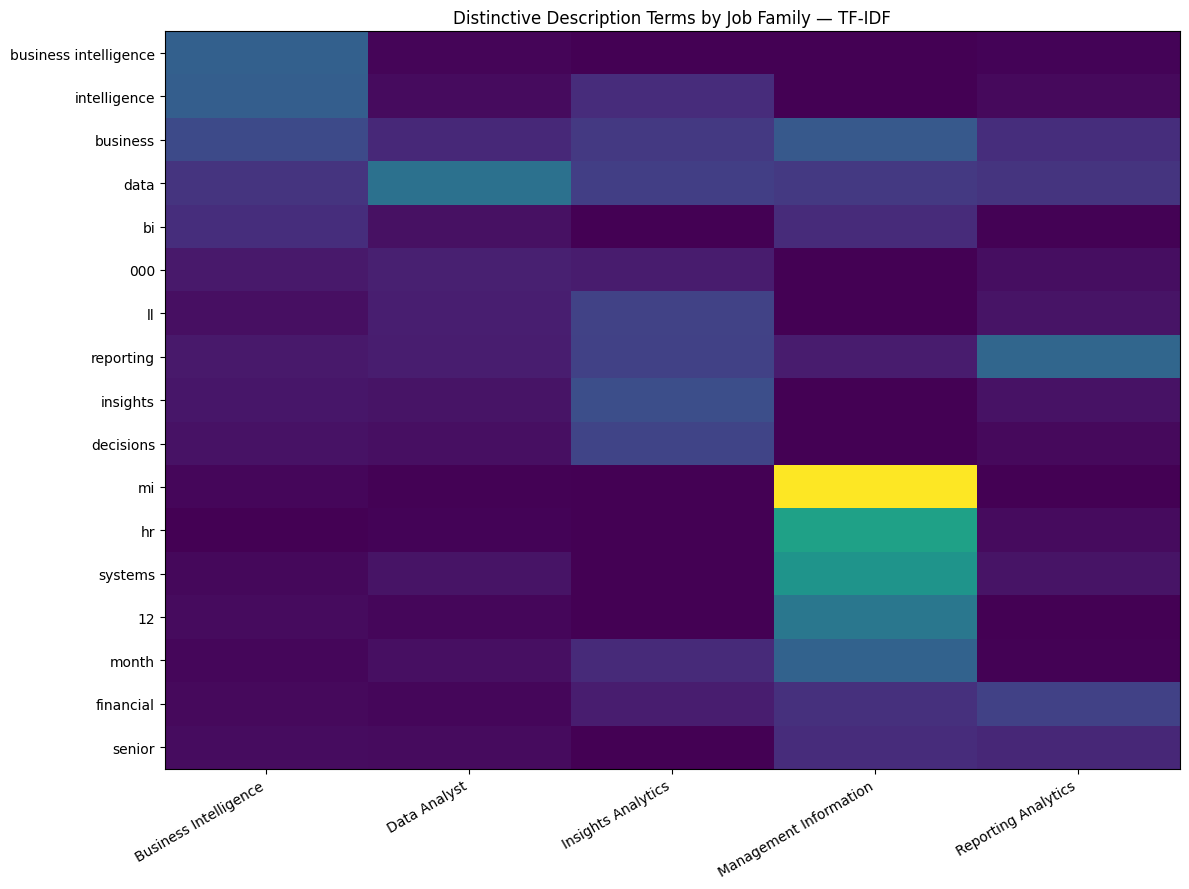

In [95]:
fig, ax = plt.subplots(
    figsize=(12, 9)
)

im = ax.imshow(
    tfidf_heatmap_plot.values,
    aspect="auto"
)

ax.set_xticks(
    range(
        len(
            tfidf_heatmap_plot.columns
        )
    )
)

ax.set_xticklabels(
    tfidf_heatmap_plot.columns,
    rotation=30,
    ha="right"
)

ax.set_yticks(
    range(
        len(
            tfidf_heatmap_plot.index
        )
    )
)

ax.set_yticklabels(
    tfidf_heatmap_plot.index
)

ax.set_title(
    "Distinctive Description Terms by Job Family — TF-IDF"
)

plt.tight_layout()
plt.show()

In [96]:
for family in family_tfidf.index:

    print("=" * 80)
    print("JOB FAMILY:", family)

    display(
        get_top_tfidf_terms(
            family_tfidf,
            family,
            n=15
        )
    )

JOB FAMILY: Business Intelligence


,term,tfidf_score
0,business intelligence,0.137604
1,intelligence,0.133588
2,business,0.101490
3,data,0.066803
4,bi,0.059145
5,world,0.052110
6,insight,0.047960
7,analysis,0.032875
8,people,0.032698
9,care,0.032179


JOB FAMILY: Data Analyst


,term,tfidf_score
0,data,0.167655
1,business,0.052591
2,000,0.039179
3,ll,0.037816
4,reporting,0.036351
5,analytics,0.032987
6,hybrid,0.030684
7,days,0.029787
8,analysis,0.028522
9,client,0.027949


JOB FAMILY: Insights Analytics


,term,tfidf_score
0,insights,0.107639
1,decisions,0.092152
2,ll,0.089163
3,reporting,0.087066
4,data,0.083061
5,trusted,0.080211
6,business,0.074088
7,insight,0.073386
8,lead,0.073369
9,shape,0.069966


JOB FAMILY: Management Information


,term,tfidf_score
0,mi,0.448954
1,hr,0.256957
2,systems,0.233190
3,12,0.178420
4,month,0.141367
5,business,0.125344
6,leading,0.105733
7,firm,0.091651
8,analytics,0.090715
9,wide,0.089210


JOB FAMILY: Reporting Analytics


,term,tfidf_score
0,reporting,0.147326
1,financial,0.086175
2,data,0.068026
3,business,0.059092
4,senior,0.049954
5,people,0.048770
6,finance,0.047504
7,key,0.046422
8,regulatory,0.039750
9,description,0.036044


### 10.7 Contextual TF-IDF Refinement

The initial TF-IDF model successfully identified distinctive vocabulary, but
many high-ranking terms reflected job-family labels themselves or generic
recruitment language.

A second contextual TF-IDF model therefore removes occupational label terms,
generic vacancy language and numeric tokens.

The purpose is to identify the surrounding business, functional and domain
language associated with each analytical job family rather than simply
rediscovering the family name.

In [98]:
context_stop_words = [
    # Generic recruitment language
    "analyst",
    "analysts",
    "role",
    "roles",
    "team",
    "join",
    "joining",
    "opportunity",
    "opportunities",
    "work",
    "working",
    "looking",
    "support",
    "company",
    "organisation",
    "organization",
    "job",
    "jobs",
    "position",
    "positions",
    "candidate",
    "candidates",
    "experience",
    "based",
    "leading",
    "global",
    "world",
    "people",
    "help",
    "key",
    "days",
    "day",
    "week",
    "hybrid",
    "start",
    "date",
    "ll",

    # Occupational labels
    "data",
    "analytics",
    "analysis",
    "business",
    "intelligence",
    "bi",
    "reporting",
    "report",
    "reports",
    "insight",
    "insights",
    "mi"
]

In [99]:
contextual_stop_words = (
    list(ENGLISH_STOP_WORDS)
    + generic_job_words
    + context_stop_words
)

In [100]:
context_tfidf_vectorizer = TfidfVectorizer(
    stop_words=contextual_stop_words,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    max_features=500,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

In [101]:
context_tfidf_matrix = (
    context_tfidf_vectorizer
    .fit_transform(
        core_market["description_clean"]
    )
)

context_terms = (
    context_tfidf_vectorizer
    .get_feature_names_out()
)

print(
    "Contextual TF-IDF matrix shape:",
    context_tfidf_matrix.shape
)

print(
    "Vocabulary size:",
    len(context_terms)
)

Contextual TF-IDF matrix shape: (244, 500)
Vocabulary size: 500


In [102]:
context_tfidf_df = pd.DataFrame(
    context_tfidf_matrix.toarray(),
    columns=context_terms,
    index=core_market.index
)

context_tfidf_df["job_family"] = (
    core_market["job_family"].values
)

In [104]:
context_family_tfidf = (
    context_tfidf_df
    .groupby("job_family")
    .mean()
)

In [105]:
primary_families = [
    "Data Analyst",
    "Business Intelligence",
    "Reporting Analytics"
]

In [106]:
for family in primary_families:

    print("=" * 80)
    print("JOB FAMILY:", family)
    print()

    display(
        get_top_tfidf_terms(
            context_family_tfidf,
            family,
            n=15
        )
    )

JOB FAMILY: Data Analyst



,term,tfidf_score
0,contract,0.030919
1,client,0.030695
2,complex,0.029699
3,dashboards,0.026684
4,systems,0.026432
5,technology,0.025679
6,analytical,0.025671
7,experienced,0.025414
8,solutions,0.025062
9,platform,0.024777


JOB FAMILY: Business Intelligence



,term,tfidf_score
0,performance,0.034594
1,play,0.033993
2,turn,0.033787
3,end,0.032580
4,strong,0.032294
5,care,0.032279
6,growing,0.031324
7,provide,0.030556
8,available,0.030088
9,life,0.029632


JOB FAMILY: Reporting Analytics



,term,tfidf_score
0,financial,0.092407
1,senior,0.052583
2,finance,0.049576
3,regulatory,0.040884
4,erp,0.038305
5,solutions,0.037144
6,description,0.036362
7,management,0.034781
8,strategic,0.034668
9,making,0.034001


In [107]:
small_sample_families = [
    "Insights Analytics",
    "Management Information"
]

for family in small_sample_families:

    print("=" * 80)
    print(
        "EXPLORATORY — SMALL SAMPLE:",
        family
    )

    display(
        get_top_tfidf_terms(
            context_family_tfidf,
            family,
            n=10
        )
    )

EXPLORATORY — SMALL SAMPLE: Insights Analytics


,term,tfidf_score
0,decisions,0.106152
1,lead,0.084716
2,trusted,0.083803
3,shape,0.078718
4,digital,0.066755
5,structured,0.061497
6,investment,0.061063
7,month,0.058909
8,home,0.058561
9,temporary contract,0.058559


EXPLORATORY — SMALL SAMPLE: Management Information


,term,tfidf_score
0,hr,0.285323
1,systems,0.258932
2,month,0.214358
3,firm,0.138972
4,term contract,0.135271
5,wide,0.135271
6,financial services,0.131959
7,directly,0.131959
8,benefits,0.128964
9,fixed term,0.126229


### 10.8 Relative Term Distinctiveness

Average TF-IDF scores can still assign relatively high importance to generic
language that occurs across many job descriptions.

To identify terms that are more characteristic of a particular job family,
each family's average TF-IDF score is compared with the overall corpus
average.

The resulting distinctiveness score highlights terms that are unusually
important within one occupational family rather than merely frequent across
the dataset.

In [108]:
overall_tfidf_mean = (
    context_tfidf_df
    .drop(columns="job_family")
    .mean()
)

overall_tfidf_mean.head()

,0
ability,0.009147
accounts,0.005458
accurate,0.010767
act,0.004978
actionable,0.014808


In [109]:
distinctiveness_scores = (
    context_family_tfidf
    .subtract(
        overall_tfidf_mean,
        axis="columns"
    )
)

In [110]:
def get_top_distinctive_terms(
    scores_df,
    family,
    n=15
):

    scores = (
        scores_df
        .loc[family]
        .sort_values(
            ascending=False
        )
        .head(n)
    )

    return pd.DataFrame({
        "term": scores.index,
        "distinctiveness_score": scores.values
    })

In [111]:
for family in primary_families:

    print("=" * 80)
    print("JOB FAMILY:", family)
    print()

    display(
        get_top_distinctive_terms(
            distinctiveness_scores,
            family,
            n=15
        )
    )

JOB FAMILY: Data Analyst



,term,distinctiveness_score
0,platform,0.009421
1,building,0.007748
2,large,0.006978
3,site,0.006881
4,engineering,0.006273
5,permanent,0.006262
6,dashboards,0.006187
7,client,0.006186
8,commercial,0.005961
9,complex,0.005803


JOB FAMILY: Business Intelligence



,term,distinctiveness_score
0,end,0.024408
1,care,0.024292
2,influence,0.023624
3,living,0.022742
4,cytel,0.020998
5,turn,0.020502
6,available,0.019082
7,life,0.018758
8,difference,0.018671
9,come,0.018064


JOB FAMILY: Reporting Analytics



,term,distinctiveness_score
0,financial,0.065946
1,senior,0.030835
2,finance,0.029191
3,regulatory,0.027629
4,erp,0.027132
5,insurance,0.026253
6,lloyd,0.026136
7,financial planning,0.024268
8,accounts,0.023493
9,planning,0.023478


In [112]:
additional_noise_words = [
    "play",
    "care",
    "life",
    "available",
    "provide",
    "make",
    "strong",
    "end",
    "turn",
    "growing",
    "experienced",
    "office",
    "description"
]

### 10.9 Employer-Stable Distinctive Terms

Some high-ranking TF-IDF terms were found to reflect employer-specific
language rather than occupational characteristics.

To reduce the influence of repeated recruitment templates and company
boilerplate, terms are retained for the final contextual analysis only when
they appear across advertisements from at least three different companies.

TF-IDF scores are also averaged at company level before being aggregated by
job family, preventing organisations with multiple advertisements from
disproportionately influencing the occupational vocabulary.

In [113]:
context_presence = pd.DataFrame(
    (context_tfidf_matrix > 0)
    .astype(int)
    .toarray(),
    columns=context_terms,
    index=core_market.index
)

context_presence["company"] = (
    core_market["company"]
    .fillna("Unknown")
    .values
)

context_presence["job_family"] = (
    core_market["job_family"]
    .values
)

In [114]:
term_company_counts = (
    context_presence
    .groupby("company")[context_terms]
    .max()
    .sum()
    .sort_values(
        ascending=False
    )
)

term_company_counts.head(30)

,0
complex,38
decision,34
experienced,34
contract,33
performance,33
making,33
decisions,33
client,32
location,32
services,31


In [115]:
stable_terms = (
    term_company_counts[
        term_company_counts >= 3
    ]
    .index
    .tolist()
)

print(
    "Original contextual vocabulary:",
    len(context_terms)
)

print(
    "Terms appearing across 3+ companies:",
    len(stable_terms)
)

Original contextual vocabulary: 500
Terms appearing across 3+ companies: 440


In [116]:
context_scores = pd.DataFrame(
    context_tfidf_matrix.toarray(),
    columns=context_terms,
    index=core_market.index
)

context_scores["company"] = (
    core_market["company"]
    .fillna("Unknown")
    .values
)

context_scores["job_family"] = (
    core_market["job_family"]
    .values
)

In [117]:
company_family_tfidf = (
    context_scores
    .groupby(
        [
            "job_family",
            "company"
        ]
    )[stable_terms]
    .mean()
    .reset_index()
)

In [118]:
balanced_family_tfidf = (
    company_family_tfidf
    .groupby("job_family")[stable_terms]
    .mean()
)

In [119]:
balanced_overall_mean = (
    company_family_tfidf[
        stable_terms
    ]
    .mean()
)

In [120]:
balanced_distinctiveness = (
    balanced_family_tfidf
    .subtract(
        balanced_overall_mean,
        axis="columns"
    )
)

In [121]:
for family in primary_families:

    print("=" * 80)
    print("JOB FAMILY:", family)
    print()

    display(
        get_top_distinctive_terms(
            balanced_distinctiveness,
            family,
            n=15
        )
    )

JOB FAMILY: Data Analyst



,term,distinctiveness_score
0,building,0.010164
1,permanent,0.008927
2,platform,0.008377
3,contract,0.008322
4,large,0.007641
5,dashboards,0.007328
6,manufacturing,0.006978
7,analytical,0.006974
8,engineering,0.006827
9,supply,0.006797


JOB FAMILY: Business Intelligence



,term,distinctiveness_score
0,care,0.028130
1,influence,0.022438
2,end,0.022354
3,available,0.019910
4,turn,0.019295
5,manager,0.017985
6,living,0.017555
7,difference,0.017339
8,drives,0.016858
9,largest,0.016447


JOB FAMILY: Reporting Analytics



,term,distinctiveness_score
0,financial,0.073111
1,finance,0.031134
2,senior,0.029508
3,financial planning,0.027373
4,accounts,0.026499
5,planning,0.026307
6,insurance,0.025897
7,description,0.024921
8,regulatory,0.023569
9,junior,0.022833


### TF-IDF Interpretation and Limitation

Contextual TF-IDF successfully identified interpretable domain language for
some occupational groups, particularly Reporting Analytics, where terms such
as financial, finance, regulatory, insurance and planning remained
distinctive after occupational labels were removed.

However, Data Analyst and especially Business Intelligence descriptions
retained substantial recruitment, sector and organisational language even
after employer balancing and cross-company filtering.

This indicates that the available Adzuna snippets do not consistently contain
enough role-specific text to support a stable occupational-language model
across all job families.

TF-IDF is therefore retained as exploratory NLP evidence rather than used as
a primary market conclusion.

## 11. Exploratory Salary Modelling

A supervised machine-learning experiment is used to investigate whether
vacancy characteristics can help explain variation in explicitly advertised
salary.

Only non-predicted salary observations are used as the target dataset.
Adzuna-predicted salary values are excluded to avoid training a model on
compensation values already generated by another predictive system.

The experiment compares a simple baseline with Decision Tree and Random Forest
regression models.

Given the relatively small sample size, results are interpreted as exploratory
rather than production-grade salary predictions.

In [122]:
ml_data = (
    core_market[
        core_market["salary_is_predicted"] == 0
    ]
    .copy()
)

print("ML salary observations:", len(ml_data))

ML salary observations: 120


In [123]:
ml_data["salary_midpoint"].describe()

,salary_midpoint
count,120.000000
mean,51868.829167
std,25209.772467
min,19200.000000
25%,35000.000000
50%,44750.000000
75%,57125.000000
max,136500.000000


In [124]:
ml_data["technology_count"] = (
    ml_data["technologies_found"]
    .apply(len)
)

ml_data["capability_count"] = (
    ml_data["capabilities_found"]
    .apply(len)
)

In [125]:
model_technologies = [
    "Power BI",
    "SQL",
    "Excel",
    "Python",
    "Tableau"
]

for technology in model_technologies:

    column_name = (
        "tech_"
        + technology
        .lower()
        .replace(" ", "_")
    )

    ml_data[column_name] = (
        ml_data["technologies_found"]
        .apply(
            lambda items:
            int(technology in items)
        )
    )

In [126]:
[
    col
    for col in ml_data.columns
    if col.startswith("tech_")
]

['tech_power_bi', 'tech_sql', 'tech_excel', 'tech_python', 'tech_tableau']

In [127]:
categorical_features = [
    "job_family",
    "seniority",
    "geo_scope",
    "contract_type",
    "contract_time"
]

numeric_features = [
    "technology_count",
    "capability_count",
    "tech_power_bi",
    "tech_sql",
    "tech_excel",
    "tech_python",
    "tech_tableau"
]

target = "salary_midpoint"

In [129]:
def classify_geo_scope(location):

    if pd.isna(location):
        return "Unknown"

    location = str(location).strip()

    if "london" in location.lower():
        return "London"

    if location.lower() == "uk":
        return "UK-wide / Unspecified"

    return "Rest of UK"


core_market["geo_scope"] = (
    core_market["location"]
    .apply(classify_geo_scope)
)

In [131]:
core_market["geo_scope"].value_counts()

,count
geo_scope,
Rest of UK,140
London,75
UK-wide / Unspecified,29


In [133]:
ml_data = (
    core_market[
        core_market["salary_is_predicted"] == 0
    ]
    .copy()
)

print("ML salary observations:", len(ml_data))

ML salary observations: 120


In [134]:
ml_data["technology_count"] = (
    ml_data["technologies_found"]
    .apply(len)
)

ml_data["capability_count"] = (
    ml_data["capabilities_found"]
    .apply(len)
)

In [135]:
model_technologies = [
    "Power BI",
    "SQL",
    "Excel",
    "Python",
    "Tableau"
]

for technology in model_technologies:

    column_name = (
        "tech_"
        + technology
        .lower()
        .replace(" ", "_")
    )

    ml_data[column_name] = (
        ml_data["technologies_found"]
        .apply(
            lambda items:
            int(technology in items)
        )
    )

In [136]:
categorical_features = [
    "job_family",
    "seniority",
    "geo_scope",
    "contract_type",
    "contract_time"
]

numeric_features = [
    "technology_count",
    "capability_count",
    "tech_power_bi",
    "tech_sql",
    "tech_excel",
    "tech_python",
    "tech_tableau"
]

target = "salary_midpoint"

required_ml_columns = (
    categorical_features
    + numeric_features
    + [target]
)

missing_ml_columns = [
    col
    for col in required_ml_columns
    if col not in ml_data.columns
]

print("Missing ML columns:", missing_ml_columns)

Missing ML columns: []


In [137]:
X = ml_data[
    categorical_features
    + numeric_features
].copy()

y = ml_data[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (120, 12)
y shape: (120,)


In [138]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [139]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [140]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

In [141]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        )
    ]
)

In [142]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [143]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

from sklearn.dummy import DummyRegressor

In [146]:
from sklearn.dummy import DummyRegressor

In [145]:
baseline_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DummyRegressor(
                strategy="median"
            )
        )
    ]
)

In [147]:
from sklearn.tree import DecisionTreeRegressor

In [148]:
decision_tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=4,
                min_samples_leaf=5,
                random_state=42
            )
        )
    ]
)

In [149]:
from sklearn.ensemble import RandomForestRegressor

In [150]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=5,
                min_samples_leaf=3,
                random_state=42
            )
        )
    ]
)

In [151]:
models = {
    "Median Baseline": baseline_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

In [152]:
model_results = []

for model_name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        }
    )

    model_results.append({
        "model": model_name,

        "MAE": (
            -scores["test_mae"].mean()
        ),

        "RMSE": (
            -scores["test_rmse"].mean()
        ),

        "R2": (
            scores["test_r2"].mean()
        )
    })

In [153]:
model_comparison = (
    pd.DataFrame(model_results)
)

model_comparison[
    ["MAE", "RMSE", "R2"]
] = (
    model_comparison[
        ["MAE", "RMSE", "R2"]
    ]
    .round(2)
)

model_comparison

,model,MAE,RMSE,R2
0,Median Baseline,17256.11,26111.57,-0.11
1,Decision Tree,16899.28,22895.06,0.15
2,Random Forest,16235.86,22401.74,0.19


### Initial Model Comparison

Random Forest achieved the strongest cross-validation performance among the
tested models, with an average MAE of approximately £16,236 and RMSE of
£22,402.

Decision Tree also outperformed the median baseline, although by a smaller
margin.

The Random Forest achieved an average out-of-sample R² of approximately 0.19,
indicating modest predictive power. Vacancy characteristics available in the
dataset explain some salary variation, but a substantial amount remains
unexplained.

Given the limited sample of 120 explicitly advertised salaries and the
restricted information available in Adzuna description snippets, the model is
treated as an exploratory salary-modelling experiment rather than a
production-ready salary predictor.

In [154]:
from sklearn.model_selection import RepeatedKFold

In [155]:
repeated_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

In [156]:
repeated_results = []

for model_name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=repeated_cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        }
    )

    repeated_results.append({
        "model": model_name,

        "MAE_mean": -scores["test_mae"].mean(),
        "MAE_std": scores["test_mae"].std(),

        "RMSE_mean": -scores["test_rmse"].mean(),
        "RMSE_std": scores["test_rmse"].std(),

        "R2_mean": scores["test_r2"].mean(),
        "R2_std": scores["test_r2"].std()
    })

In [157]:
repeated_model_comparison = (
    pd.DataFrame(repeated_results)
)

numeric_result_cols = [
    "MAE_mean",
    "MAE_std",
    "RMSE_mean",
    "RMSE_std",
    "R2_mean",
    "R2_std"
]

repeated_model_comparison[
    numeric_result_cols
] = (
    repeated_model_comparison[
        numeric_result_cols
    ]
    .round(2)
)

repeated_model_comparison

,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Median Baseline,17261.92,3031.58,25912.55,4410.11,-0.11,0.10
1,Decision Tree,17017.00,2718.25,23202.58,3258.89,0.07,0.29
2,Random Forest,16663.18,2695.96,22828.09,3299.84,0.09,0.31


In [158]:
from sklearn.model_selection import cross_val_predict

In [159]:
rf_oof_predictions = cross_val_predict(
    random_forest_model,
    X,
    y,
    cv=cv
)

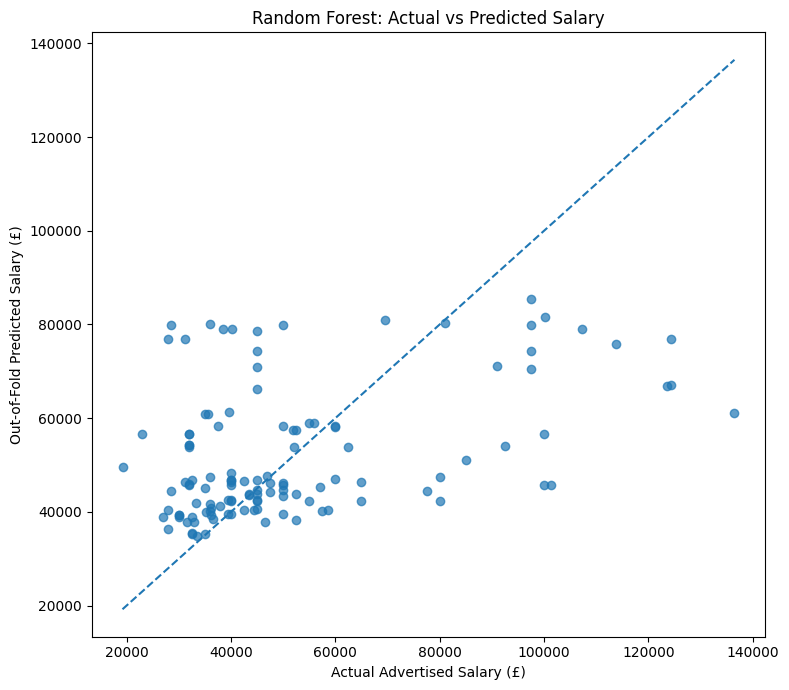

In [160]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    y,
    rf_oof_predictions,
    alpha=0.7
)

min_salary = min(
    y.min(),
    rf_oof_predictions.min()
)

max_salary = max(
    y.max(),
    rf_oof_predictions.max()
)

ax.plot(
    [min_salary, max_salary],
    [min_salary, max_salary],
    linestyle="--"
)

ax.set_title(
    "Random Forest: Actual vs Predicted Salary"
)

ax.set_xlabel(
    "Actual Advertised Salary (£)"
)

ax.set_ylabel(
    "Out-of-Fold Predicted Salary (£)"
)

plt.tight_layout()
plt.show()

### Model Stability and Predictive Performance

Repeated 5-fold cross-validation confirms that Random Forest performs slightly
better than both the Decision Tree and median baseline.

However, the improvement is modest. Random Forest reduces mean absolute error
by approximately 3.5% relative to the median baseline and achieves an average
R² of only 0.09.

Performance also varies substantially across cross-validation folds,
indicating limited model stability.

Out-of-fold predictions show regression toward the centre of the salary
distribution: lower salaries are often overestimated, while high salaries are
frequently underestimated.

The experiment therefore suggests that the available vacancy characteristics
contain some salary signal, but are insufficient for accurate individual
salary prediction.

### 11.10 Cross-Validated Permutation Importance

Permutation importance is used to estimate how much each original feature
contributes to predictive performance.

For each cross-validation fold, the model is trained on the training data and
feature values are randomly permuted within the validation data.

A feature is considered more important when disrupting it causes a larger
increase in prediction error.

In [161]:
from sklearn.inspection import permutation_importance

In [162]:
permutation_results = []

for fold, (train_idx, test_idx) in enumerate(
    cv.split(X),
    start=1
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    random_forest_model.fit(
        X_train,
        y_train
    )

    result = permutation_importance(
        random_forest_model,
        X_test,
        y_test,
        scoring="neg_mean_absolute_error",
        n_repeats=20,
        random_state=42
    )

    for feature, importance in zip(
        X.columns,
        result.importances_mean
    ):

        permutation_results.append({
            "fold": fold,
            "feature": feature,
            "importance": importance
        })

In [163]:
permutation_importance_summary = (
    pd.DataFrame(permutation_results)
    .groupby("feature")
    .agg(
        mean_importance=("importance", "mean"),
        std_importance=("importance", "std")
    )
    .reset_index()
    .sort_values(
        "mean_importance",
        ascending=False
    )
)

permutation_importance_summary

,feature,mean_importance,std_importance
2,contract_type,2872.602421,165.960270
3,geo_scope,1896.477740,513.103384
4,job_family,716.629611,350.838788
7,tech_power_bi,258.575833,100.816478
10,tech_tableau,0.000000,0.000000
8,tech_python,0.000000,0.000000
1,contract_time,-1.900611,4.442661
9,tech_sql,-7.914610,11.878771
6,tech_excel,-9.852210,14.196014
5,seniority,-19.397695,52.745819


In [164]:
scoring="neg_mean_absolute_error"

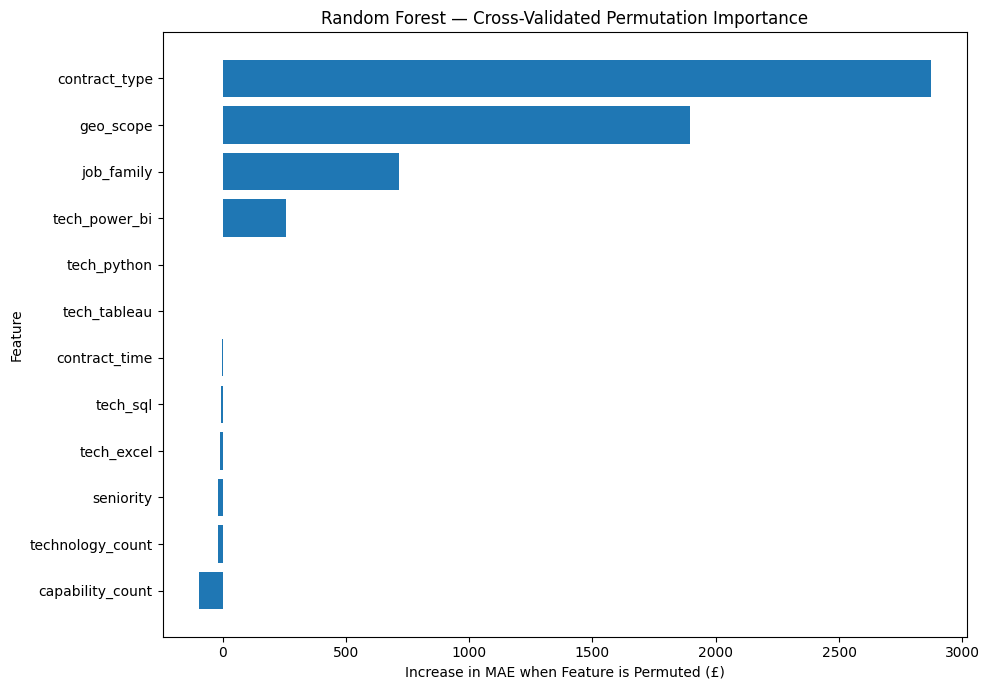

In [165]:
importance_plot = (
    permutation_importance_summary
    .sort_values("mean_importance")
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    importance_plot["feature"],
    importance_plot["mean_importance"]
)

ax.set_title(
    "Random Forest — Cross-Validated Permutation Importance"
)

ax.set_xlabel(
    "Increase in MAE when Feature is Permuted (£)"
)

ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

### Feature Importance — Interpretation

Cross-validated permutation importance indicates that contract type,
geographic scope and job family provide the strongest predictive signal in
the Random Forest model.

Contract type produces the largest deterioration in validation MAE when
permuted, followed by geographic scope and job family.

Technology indicators contribute substantially less predictive information.
Power BI shows a small positive contribution, while SQL, Excel, Python and
Tableau provide little or no stable predictive improvement in this sample.

Several features show near-zero or slightly negative permutation importance.
This does not indicate a negative salary effect; rather, it suggests that
those variables do not provide stable out-of-sample predictive information
given the available dataset.

The high importance of contract type must also be interpreted alongside an
important source-data limitation: some contract day or hourly rates are
annualised by Adzuna, which may amplify observed salary differences between
contract and permanent vacancies.

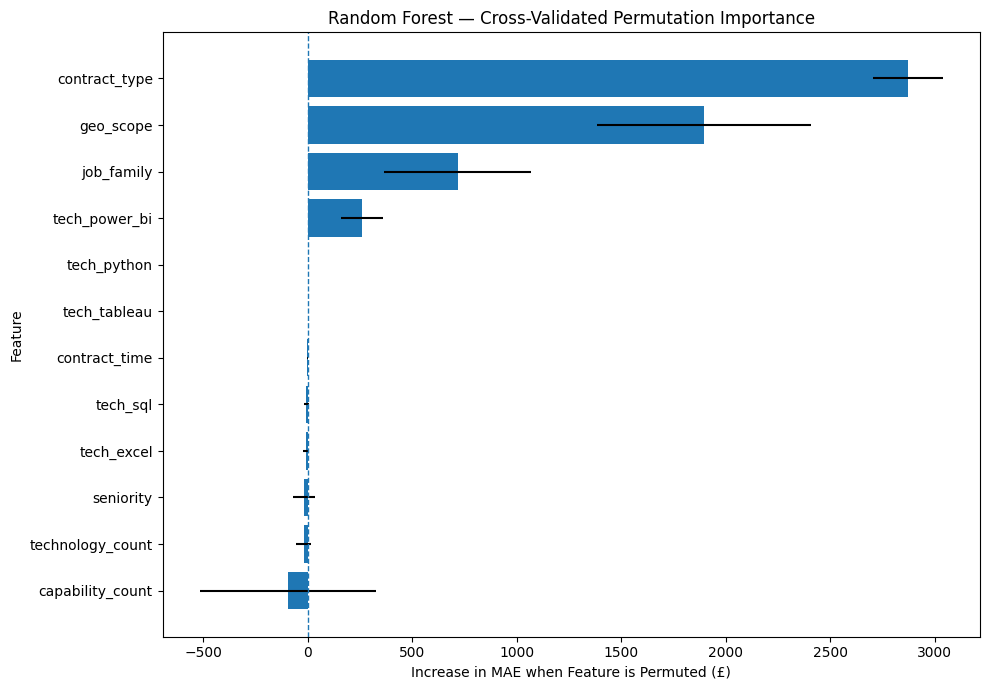

In [166]:
importance_plot = (
    permutation_importance_summary
    .sort_values("mean_importance")
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    importance_plot["feature"],
    importance_plot["mean_importance"],
    xerr=importance_plot["std_importance"]
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Random Forest — Cross-Validated Permutation Importance"
)

ax.set_xlabel(
    "Increase in MAE when Feature is Permuted (£)"
)

ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [167]:
from sklearn.ensemble import GradientBoostingRegressor

In [168]:
gradient_boosting_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=2,
                min_samples_leaf=5,
                random_state=42
            )
        )
    ]
)

In [169]:
models_extended = {
    "Median Baseline": baseline_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

In [170]:
extended_results = []

for model_name, model in models_extended.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=repeated_cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        }
    )

    extended_results.append({
        "model": model_name,
        "MAE_mean": -scores["test_mae"].mean(),
        "MAE_std": scores["test_mae"].std(),
        "RMSE_mean": -scores["test_rmse"].mean(),
        "RMSE_std": scores["test_rmse"].std(),
        "R2_mean": scores["test_r2"].mean(),
        "R2_std": scores["test_r2"].std()
    })

In [171]:
final_model_comparison = (
    pd.DataFrame(extended_results)
)

result_cols = [
    "MAE_mean",
    "MAE_std",
    "RMSE_mean",
    "RMSE_std",
    "R2_mean",
    "R2_std"
]

final_model_comparison[result_cols] = (
    final_model_comparison[result_cols]
    .round(2)
)

final_model_comparison.sort_values("MAE_mean")

,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
3,Gradient Boosting,16590.89,2513.15,22351.08,3141.83,0.14,0.26
2,Random Forest,16663.18,2695.96,22828.09,3299.84,0.09,0.31
1,Decision Tree,17017.00,2718.25,23202.58,3258.89,0.07,0.29
0,Median Baseline,17261.92,3031.58,25912.55,4410.11,-0.11,0.10


### Final Model Comparison

Gradient Boosting achieved the strongest repeated cross-validation performance
among the evaluated models.

Its mean absolute error was approximately £16,591, compared with £17,262 for
the median baseline, representing an improvement of approximately 3.9%.

Gradient Boosting also achieved the lowest RMSE (£22,351) and the highest
average R² (0.14).

Although the tree-based models extract some predictive signal from vacancy
characteristics, overall predictive performance remains modest. The available
features and limited sample of 120 explicitly advertised salaries are therefore
insufficient for accurate individual salary prediction.

The modelling exercise is consequently interpreted as an exploratory analysis
of salary structure rather than a production-ready salary prediction system.

In [172]:
gb_permutation_results = []

for fold, (train_idx, test_idx) in enumerate(
    cv.split(X),
    start=1
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    gradient_boosting_model.fit(
        X_train,
        y_train
    )

    result = permutation_importance(
        gradient_boosting_model,
        X_test,
        y_test,
        scoring="neg_mean_absolute_error",
        n_repeats=20,
        random_state=42
    )

    for feature, importance in zip(
        X.columns,
        result.importances_mean
    ):

        gb_permutation_results.append({
            "fold": fold,
            "feature": feature,
            "importance": importance
        })

In [173]:
gb_permutation_importance = (
    pd.DataFrame(gb_permutation_results)
    .groupby("feature")
    .agg(
        mean_importance=("importance", "mean"),
        std_importance=("importance", "std")
    )
    .reset_index()
    .sort_values(
        "mean_importance",
        ascending=False
    )
)

gb_permutation_importance

,feature,mean_importance,std_importance
2,contract_type,2914.844590,364.353211
3,geo_scope,2026.676024,220.375543
4,job_family,844.683328,130.610480
9,tech_sql,55.951701,88.973583
7,tech_power_bi,24.486290,120.266261
6,tech_excel,4.325026,9.671051
10,tech_tableau,0.000000,0.000000
1,contract_time,0.000000,0.000000
8,tech_python,0.000000,0.000000
5,seniority,-13.482456,20.578809


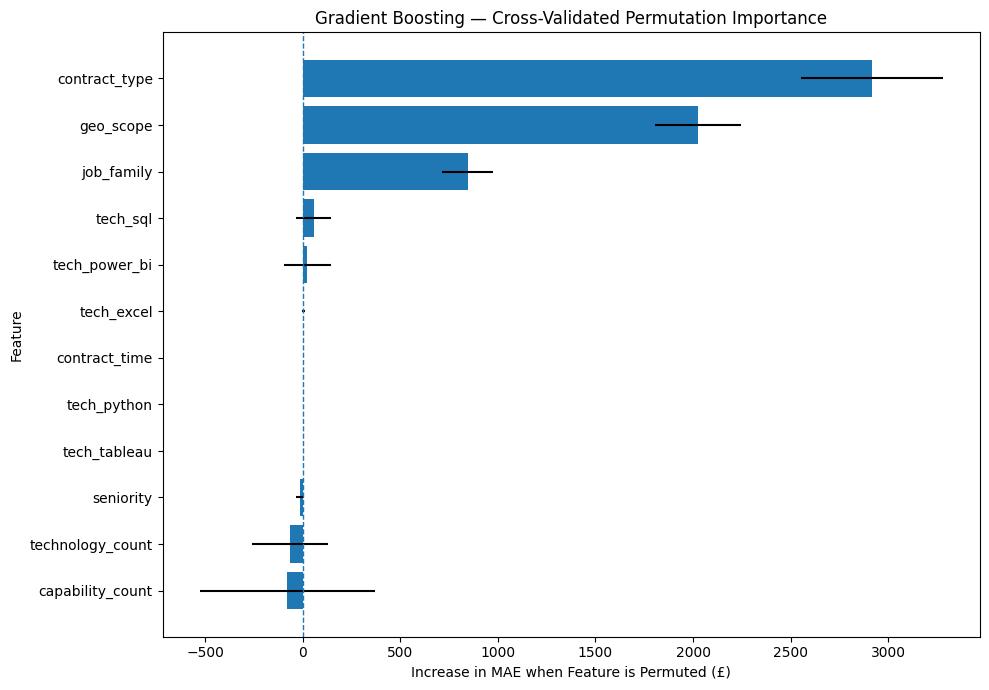

In [174]:
gb_importance_plot = (
    gb_permutation_importance
    .sort_values("mean_importance")
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    gb_importance_plot["feature"],
    gb_importance_plot["mean_importance"],
    xerr=gb_importance_plot["std_importance"]
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Gradient Boosting — Cross-Validated Permutation Importance"
)

ax.set_xlabel(
    "Increase in MAE when Feature is Permuted (£)"
)

ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [175]:
gb_oof_predictions = cross_val_predict(
    gradient_boosting_model,
    X,
    y,
    cv=cv
)

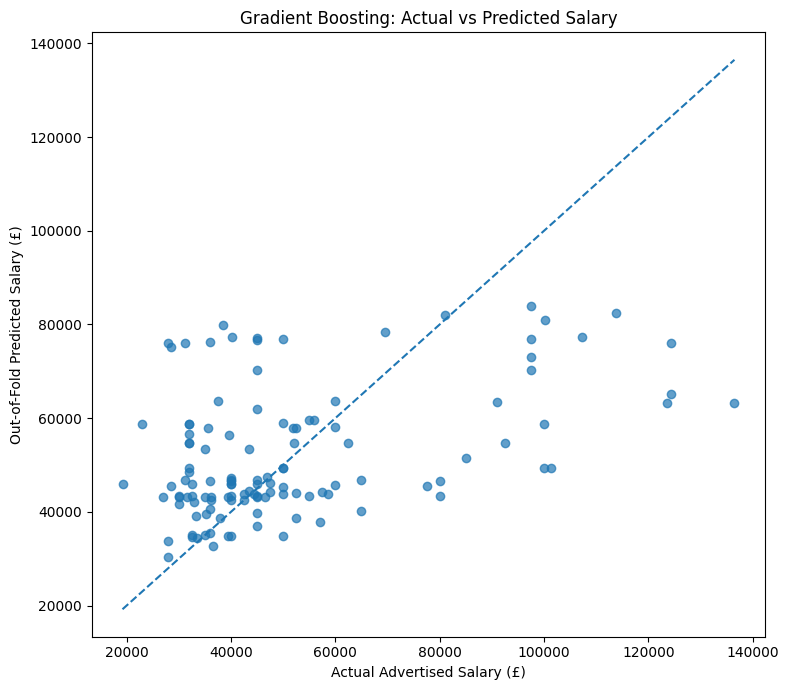

In [176]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    y,
    gb_oof_predictions,
    alpha=0.7
)

min_salary = min(
    y.min(),
    gb_oof_predictions.min()
)

max_salary = max(
    y.max(),
    gb_oof_predictions.max()
)

ax.plot(
    [min_salary, max_salary],
    [min_salary, max_salary],
    linestyle="--"
)

ax.set_title(
    "Gradient Boosting: Actual vs Predicted Salary"
)

ax.set_xlabel(
    "Actual Advertised Salary (£)"
)

ax.set_ylabel(
    "Out-of-Fold Predicted Salary (£)"
)

plt.tight_layout()
plt.show()

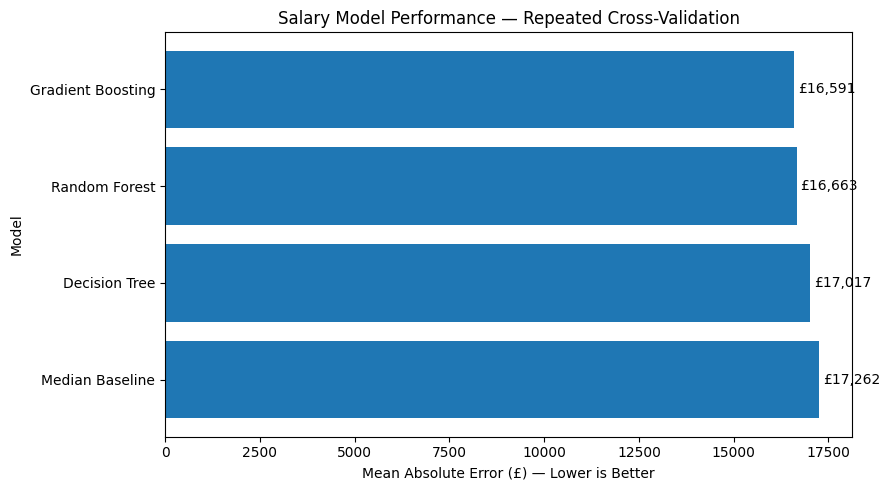

In [177]:
model_plot = (
    final_model_comparison
    .sort_values("MAE_mean", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    model_plot["model"],
    model_plot["MAE_mean"]
)

ax.set_title(
    "Salary Model Performance — Repeated Cross-Validation"
)

ax.set_xlabel(
    "Mean Absolute Error (£) — Lower is Better"
)

ax.set_ylabel("Model")

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 100,
        bar.get_y() + bar.get_height() / 2,
        f"£{width:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

EDA
↓
Contract type → grande diferença salarial
Geography → London premium importante
Job family → diferenças salariais

Random Forest
↓
Contract type
Geo scope
Job family

Gradient Boosting
↓
Contract type
Geo scope
Job family

### Final Feature-Importance Interpretation

Cross-validated permutation importance for the best-performing Gradient
Boosting model confirms that contract type, geographic scope and job family
contain the strongest salary-prediction signal.

Permuting contract type increases validation MAE by approximately £2,915,
while disrupting geographic scope increases MAE by approximately £2,027.
Job family provides a smaller but still meaningful contribution.

Individual technology indicators contribute little stable predictive
information. SQL, Power BI and Excel show only marginal importance, while
Python and Tableau provide no measurable improvement in this experiment.

The results reinforce patterns identified independently during exploratory
analysis: salary variation in the observed sample is more strongly associated
with employment structure, geography and occupational context than with an
individual technology mention.

Permutation importance measures predictive contribution rather than causal
salary effects.

Contract-type importance should also be interpreted cautiously because some
daily or hourly contract rates are annualised by Adzuna.

In [178]:
final_ml_summary = (
    final_model_comparison[
        [
            "model",
            "MAE_mean",
            "MAE_std",
            "RMSE_mean",
            "R2_mean"
        ]
    ]
    .sort_values("MAE_mean")
    .reset_index(drop=True)
)

final_ml_summary

,model,MAE_mean,MAE_std,RMSE_mean,R2_mean
0,Gradient Boosting,16590.89,2513.15,22351.08,0.14
1,Random Forest,16663.18,2695.96,22828.09,0.09
2,Decision Tree,17017.00,2718.25,23202.58,0.07
3,Median Baseline,17261.92,3031.58,25912.55,-0.11


In [179]:
best_model = (
    final_ml_summary
    .iloc[0]
)

print("Best model:", best_model["model"])
print(
    f"Mean MAE: £{best_model['MAE_mean']:,.0f}"
)
print(
    f"Mean RMSE: £{best_model['RMSE_mean']:,.0f}"
)
print(
    f"Mean R²: {best_model['R2_mean']:.2f}"
)

Best model: Gradient Boosting
Mean MAE: £16,591
Mean RMSE: £22,351
Mean R²: 0.14


## 12. Key Findings

### Technology mentions

Power BI is the most frequently observed technology in the Core Analytics
description snippets, followed by SQL and Excel.

However, explicit technology coverage is limited. This reflects the truncated
nature of Adzuna job-description snippets and means observed mention rates
should not be interpreted as complete market requirement rates.

### Analytical capabilities

Reporting is the most frequently observed analytical capability, appearing in
40.2% of Core Analytics snippets.

Dashboarding and Data Analysis are also recurrent, while more specialised
capabilities such as Data Modelling, Data Quality and Data Transformation
appear less frequently.

### Technology combinations

The most frequently observed technology combinations include Excel + Power BI,
Power BI + SQL, Excel + SQL and Python + SQL.

Co-occurrence is relatively sparse, so these combinations are treated as
observed patterns rather than representative market-wide technology stacks.

### Technology and salary

Among technologies with sufficient advertised-salary observations, no large
salary difference is evident.

Power BI and Excel mentions are associated with only small differences in
median advertised salary, while SQL shows little difference.

### NLP

TF-IDF analysis identified meaningful domain vocabulary for some occupational
groups, particularly Reporting Analytics, which is associated with financial,
regulatory, insurance and planning terminology.

Other job families retained substantial organisational and recruitment
language, limiting the reliability of TF-IDF as a primary market conclusion.

### Exploratory machine learning

Decision Tree, Random Forest and Gradient Boosting regression models were
evaluated against a median baseline using repeated cross-validation.

Gradient Boosting achieved the best performance, with an average MAE of
approximately £16.6k and R² of 0.14.

Although this improves on the baseline, predictive accuracy remains modest.

Permutation importance indicates that contract type, geographic scope and job
family provide substantially more predictive information than individual
technology mentions.

The modelling experiment therefore supports explanatory market analysis but
does not provide sufficient accuracy for production-grade salary prediction.

In [180]:
SKILLS_PATH = f"{PROJECT_PATH}/data/skills_outputs"

import os

os.makedirs(
    SKILLS_PATH,
    exist_ok=True
)

In [181]:
technology_summary.to_csv(
    f"{SKILLS_PATH}/technology_mentions.csv",
    index=False
)

capability_summary.to_csv(
    f"{SKILLS_PATH}/capability_mentions.csv",
    index=False
)

technology_pair_summary.to_csv(
    f"{SKILLS_PATH}/technology_cooccurrence.csv",
    index=False
)

technology_jaccard.to_csv(
    f"{SKILLS_PATH}/technology_jaccard.csv",
    index=False
)

technology_salary_summary.to_csv(
    f"{SKILLS_PATH}/technology_salary_association.csv",
    index=False
)

final_ml_summary.to_csv(
    f"{SKILLS_PATH}/ml_model_comparison.csv",
    index=False
)

gb_permutation_importance.to_csv(
    f"{SKILLS_PATH}/gradient_boosting_feature_importance.csv",
    index=False
)

In [182]:
for file in sorted(
    os.listdir(SKILLS_PATH)
):
    print(file)

capability_mentions.csv
gradient_boosting_feature_importance.csv
ml_model_comparison.csv
technology_cooccurrence.csv
technology_jaccard.csv
technology_mentions.csv
technology_salary_association.csv
